## Batch -13 Mini Project: Supervised Machine Learning - (Insurance Premium Prediction) Richa Trivedi 

## Task - 1 : Import and Load the Data
## •	Import required libraries (pandas, numpy, matplotlib, seaborn, sklearn, etc.)

In [26]:
# Import Required Libraries
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
import xgboost
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import BaggingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer
sns.set()
%matplotlib inline

In [ ]:
# •	Load the dataset and explore the structure using .head(), .info() and .describe()
import pandas as pd

# Load the Health Insurance dataset
df = pd.read_csv('Health_Insurance.csv')
print(df.head())
print(f"Dataset shape: {df.shape}")

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Dataset shape: (1338, 7)


In [21]:
df.info()
display(df.describe(include='all'))


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


## Task 3: Missing Values & Outlier Treatment

In [ ]:
# •	Check for missing values and treat them if any

missing_values = df.isnull().sum()

# Display columns with missing values
print("Missing values per column:")
print(missing_values[missing_values > 0])

if (missing_values == 0).all():
    print("No missing values found in the DataFrame.")

Missing values per column:
Series([], dtype: int64)
No missing values found in the DataFrame.


In [24]:
 # Check for duplicate records
duplicates_count = df.duplicated().sum()

print(f"Number of duplicate records found: {duplicates_count}")

# If duplicates exist, remove them
if duplicates_count > 0:
    initial_rows = df.shape[0]
    df.drop_duplicates(inplace=True)
    final_rows = df.shape[0]
    print(f"Original number of records: {initial_rows}")
    print(f"Number of records after removing duplicates: {final_rows}")
    print(f"Successfully removed {initial_rows - final_rows} duplicate records.")
else:
    print("No duplicate records found.")

Number of duplicate records found: 0
No duplicate records found.


## Task -2 . Exploratory Data Analysis (EDA)

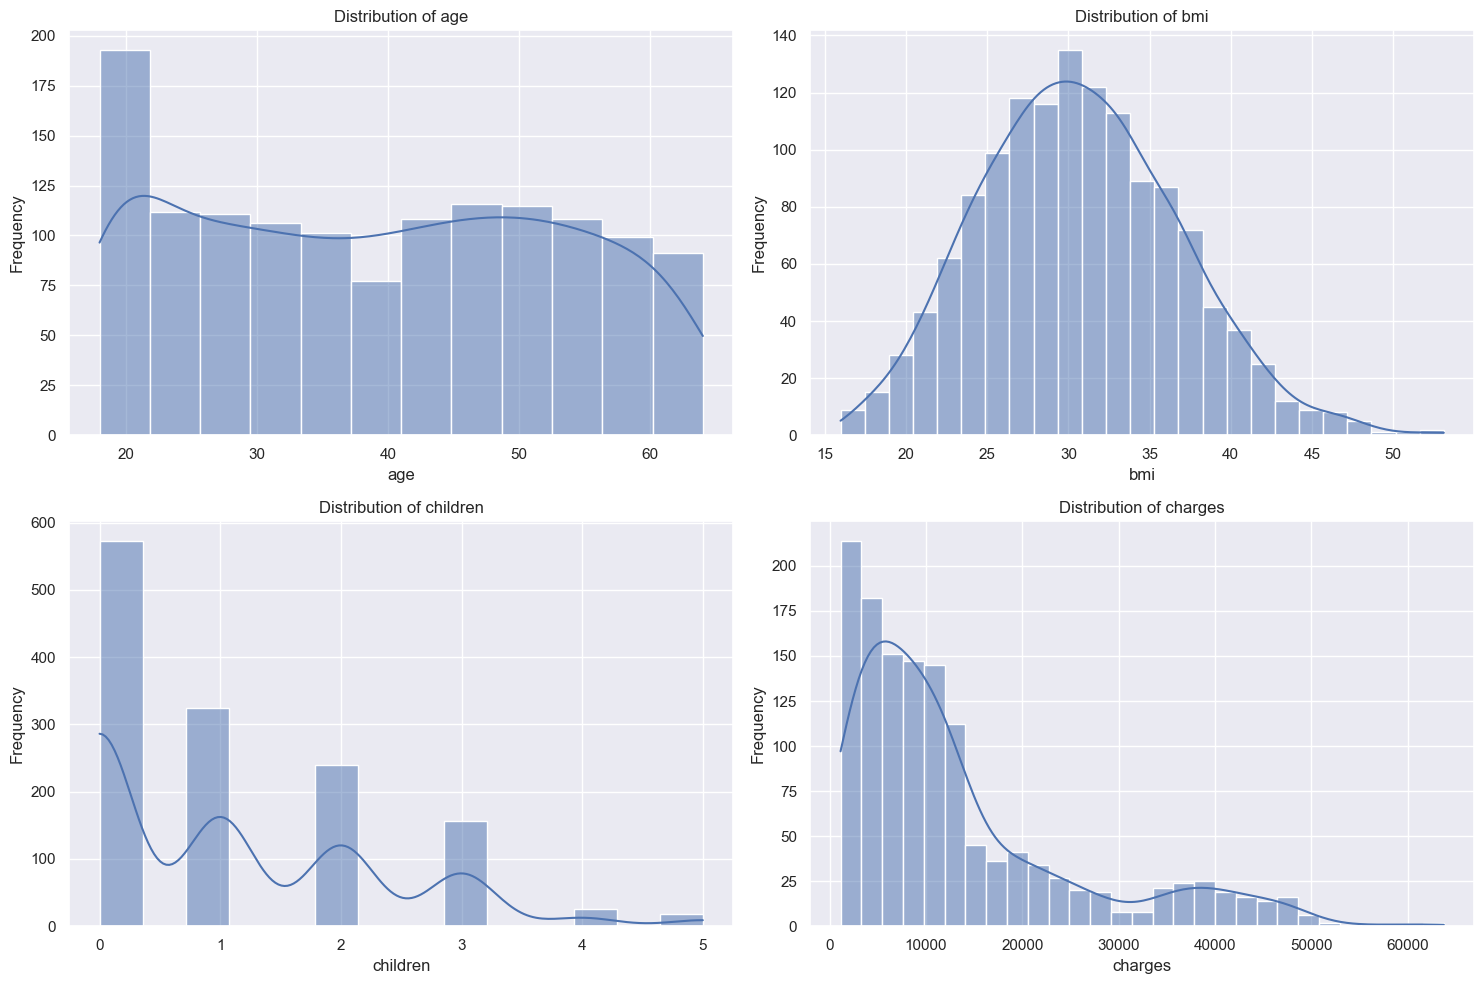

In [27]:
# •	Visualize the distribution of each feature
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure size for better readability
plt.figure(figsize=(15, 10))

# Visualize numerical features using histograms
num_cols = ['age', 'bmi', 'children', 'charges']
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

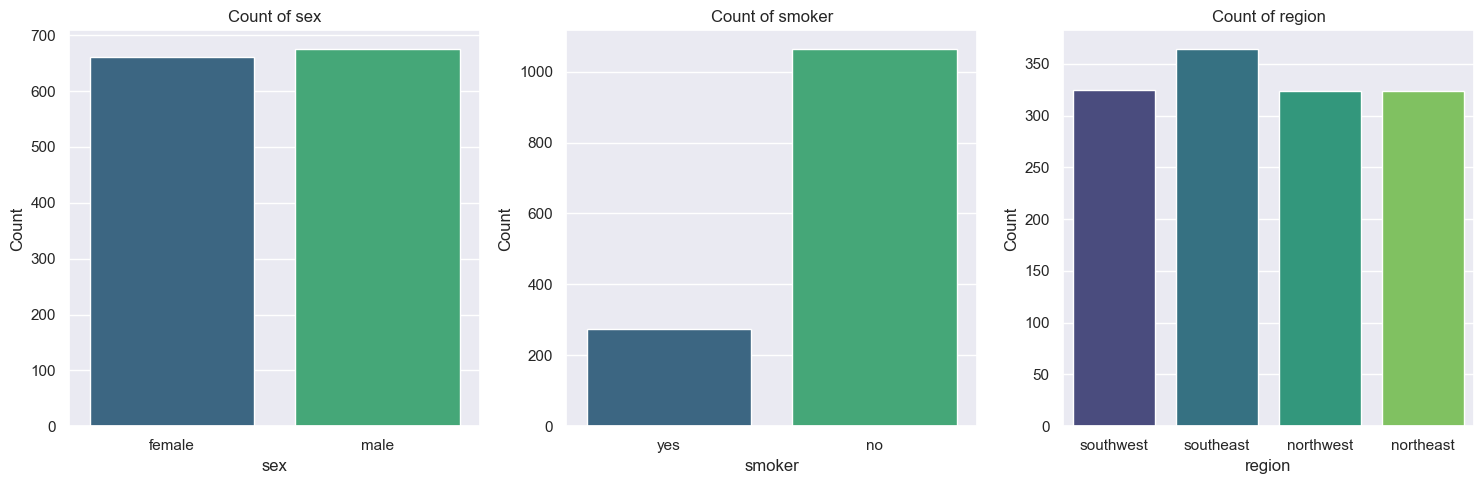

In [28]:
# Visualize categorical features using count plots
cat_cols = ['sex', 'smoker', 'region']
plt.figure(figsize=(15, 5))
for i, col in enumerate(cat_cols):
    plt.subplot(1, 3, i + 1) # Arrange plots in a 1x3 grid
    sns.countplot(x=df[col], hue=df[col], palette='viridis', legend=False)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

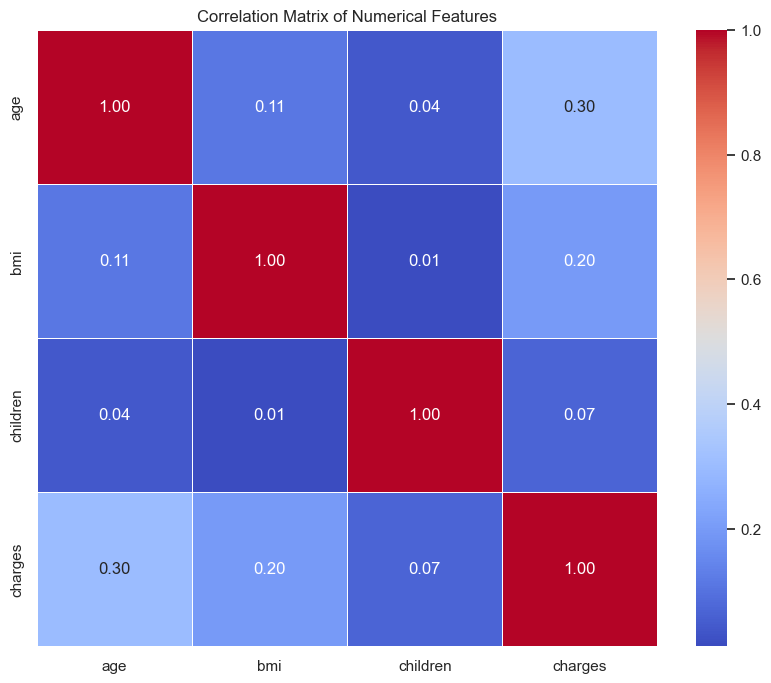

In [29]:
# •	Understand correlations (especially with the target variable)
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numerical features
correlation_matrix = df[num_cols].corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [71]:
## Scatter Plot

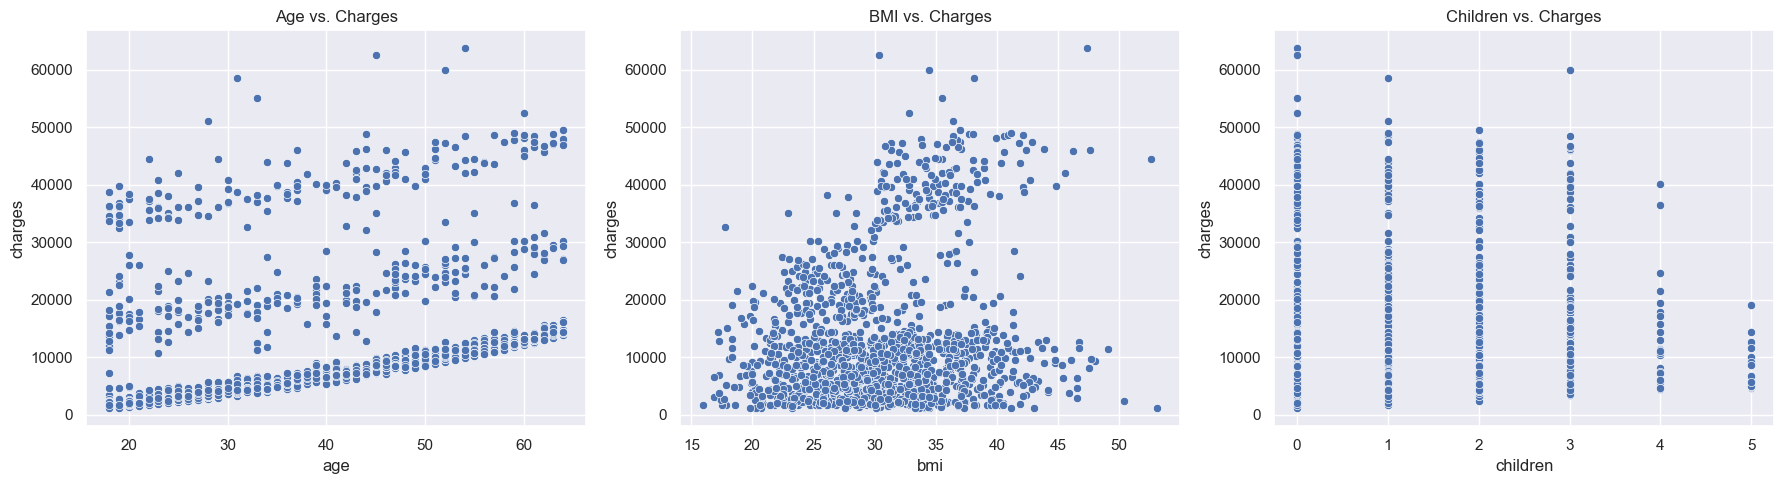

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create scatter plots for numerical features against 'charges'
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='age', y='charges', data=df)
plt.title('Age vs. Charges')

plt.subplot(1, 3, 2)
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title('BMI vs. Charges')

plt.subplot(1, 3, 3)
sns.scatterplot(x='children', y='charges', data=df)
plt.title('Children vs. Charges')

plt.tight_layout()
plt.show()

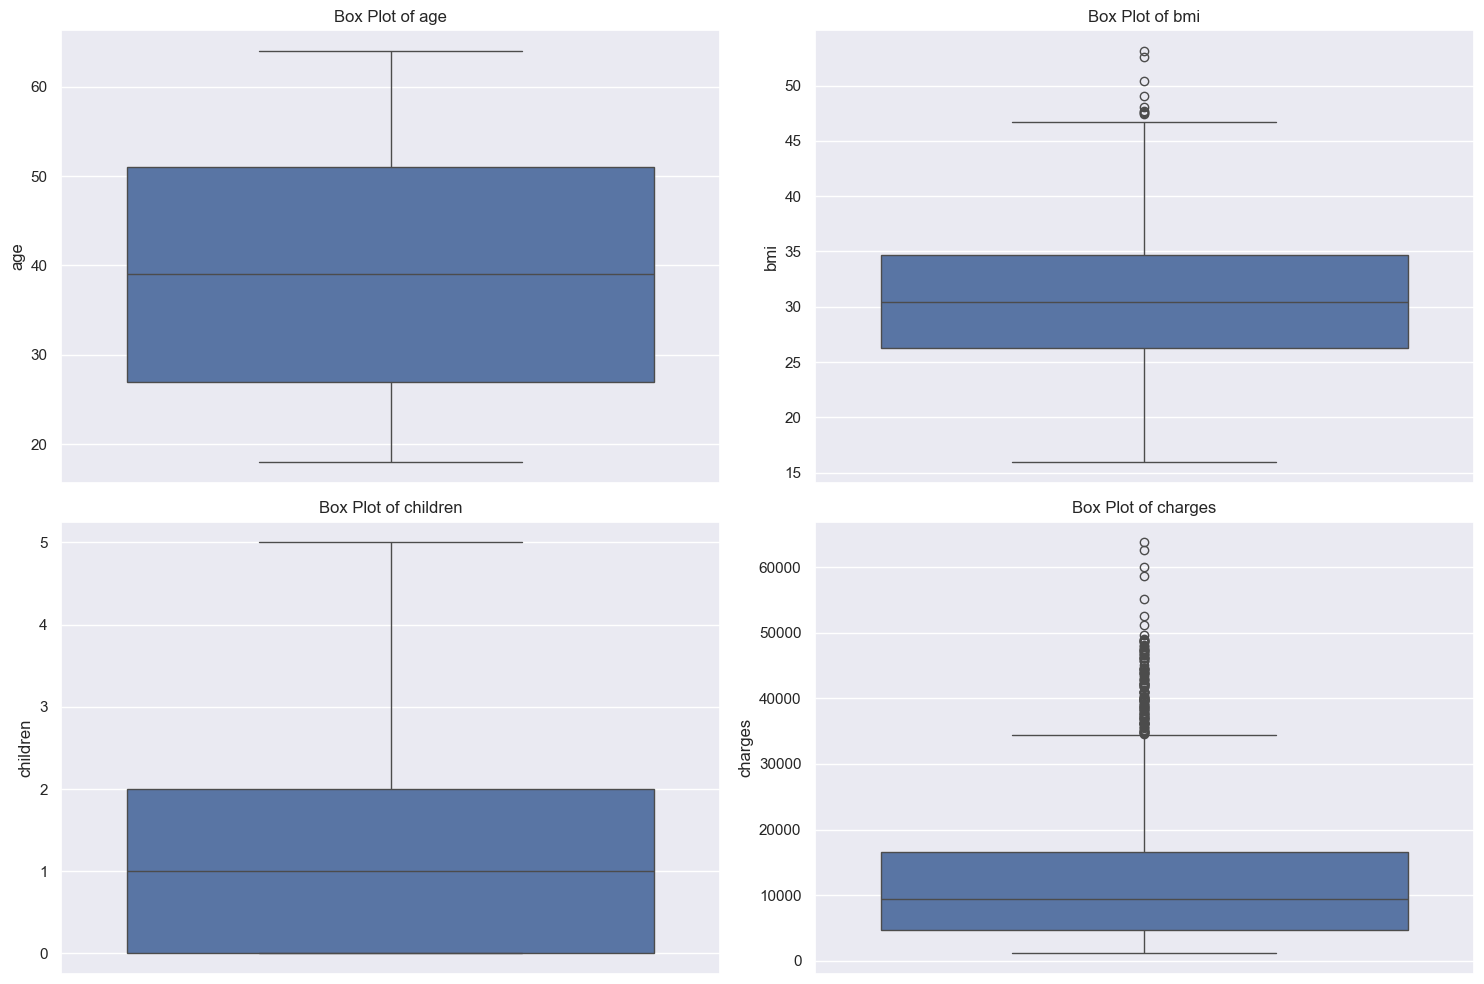

In [31]:
#Task -3 •	Check if there are any outliers.
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure size for better readability
plt.figure(figsize=(15, 10))

# Create box plots for numerical features
num_cols = ['age', 'bmi', 'children', 'charges']
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [33]:
# Removing Outliers using IQR Method
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    num_outliers = len(df) - len(df_filtered)
    print(f"Removed {num_outliers} outliers from '{column}' using IQR method.")
    return df_filtered

# Apply outlier removal to 'bmi' and 'charges' columns
initial_rows_before_outliers = df.shape[0]
df_no_outliers = df.copy()

df_no_outliers = remove_outliers_iqr(df_no_outliers, 'bmi')
df_no_outliers = remove_outliers_iqr(df_no_outliers, 'charges')

print(f"Original number of rows: {initial_rows_before_outliers}")
print(f"Number of rows after outlier removal: {df_no_outliers.shape[0]}")

df = df_no_outliers.copy()
display(df.head())

Removed 7 outliers from 'bmi' using IQR method.
Removed 53 outliers from 'charges' using IQR method.
Original number of rows: 1190
Number of rows after outlier removal: 1130


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Task 4 - Feature Engineering & Preprocessing


1. **One-Hot Encoding**: Convert categorical variables (sex, smoker, region) to numerical form
2. **Feature Scaling**: Scale ONLY the numerical FEATURES (age, bmi, children) - NOT the target variable (charges)
   - This prevents data leakage and ensures the scaler can be applied consistently in production
   - The scaler in production will only receive these 3 numerical columns

**Production Deployment Flow:**
- Input from user (raw categorical values) → One-hot encode → Scale numericals → Model prediction ✅



In [73]:
# •	Encode categorical variables (sex, smoker, region)
# Step 1: Apply one-hot encoding to categorical columns
cat_cols = ['sex', 'smoker', 'region']

# Apply one-hot encoding with drop_first=True to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

print("\nDataFrame shape after one-hot encoding:", df_encoded.shape)
print("Columns after one-hot encoding:")
print(df_encoded.columns.tolist())
print("\nExample DataFrame Head After One-Hot Encoding:")
display(df_encoded.head())

# Update df to use the encoded version
df = df_encoded.copy()
print("\nDataFrame updated with encoded categorical variables")


DataFrame shape after one-hot encoding: (1338, 9)
Columns after one-hot encoding:
['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

Example DataFrame Head After One-Hot Encoding:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0



DataFrame updated with encoded categorical variables


In [75]:
# Step 2: Feature scaling for NUMERICAL features only (NOT the target 'charges')
from sklearn.preprocessing import StandardScaler
import joblib

# Important: Scale ONLY the numerical FEATURE columns


num_cols_to_scale = ['age', 'bmi', 'children']  # Only features, not target!

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling ONLY to the numerical feature columns
df[num_cols_to_scale] = scaler.fit_transform(df[num_cols_to_scale])

print(f"\n✅ Scaled numerical columns: {num_cols_to_scale}")
print("\nDataFrame after scaling:")
display(df.head())

# Save the scaler for deployment (it knows about the 3 numerical columns)
print("\n📊 Scaler fitted on columns:", num_cols_to_scale)
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved as 'scaler.pkl'")


✅ Scaled numerical columns: ['age', 'bmi', 'children']

DataFrame after scaling:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.438764,-0.453320,-0.908614,16884.92400,0,1,0,0,1
1,-1.509965,0.509621,-0.078767,1725.55230,1,0,0,1,0
2,-0.797954,0.383307,1.580926,4449.46200,1,0,0,1,0
3,-0.441948,-1.305531,-0.908614,21984.47061,1,0,1,0,0
4,-0.513149,-0.292556,-0.908614,3866.85520,1,0,1,0,0



📊 Scaler fitted on columns: ['age', 'bmi', 'children']
✅ Scaler saved as 'scaler.pkl'


In [76]:

# Step 3: Check for skewness in numerical features
# Note: Skewness check is performed on the SCALED features (age, bmi, children)
# and the TARGET variable (charges) before separating them

print("\n📊 IMPORTANT: Scaler was fit on ONLY 3 numerical features:")
print("   - age, bmi, children (NOT charges)")
print("   - One-hot encoded columns (sex_*, smoker_*, region_*) are NOT scaled")
print("\nThis is the CORRECT approach to avoid data leakage!\n")

# Identify numerical columns for skewness analysis
num_cols = ['age', 'bmi', 'children', 'charges']

# Calculate skewness for each numerical column
skewness_values = df[num_cols].skew()

print("Skewness of numerical features:\n", skewness_values)

# Treat skewness for highly skewed columns (e.g., using log transformation)
# A common threshold for significant skewness is > 0.5 or < -0.5

# Check for columns with high positive skewness
high_positive_skew_cols = skewness_values[skewness_values > 0.5].index.tolist()
if high_positive_skew_cols:
    print(f"\nApplying log transformation to positively skewed columns: {high_positive_skew_cols}")
    for col in high_positive_skew_cols:
        # Add a small constant to avoid log(0) if any values are zero
        df[col] = np.log1p(df[col] - df[col].min() + 1e-6)

# Check for columns with high negative skewness (less common for right-skewed data)
high_negative_skew_cols = skewness_values[skewness_values < -0.5].index.tolist()
if high_negative_skew_cols:
    print(f"\nApplying inverse transformation (e.g., square) to negatively skewed columns: {high_negative_skew_cols}")
    # For negative skew, more complex transformations might be needed, or consider inverse
    
    for col in high_negative_skew_cols:
        
        df[col] = np.square(df[col]) # This is a placeholder; actual treatment depends on data nature


# Display the new skewness after transformation
print("\nSkewness after transformation (if any):\n", df[num_cols].skew())
display(df.head())


📊 IMPORTANT: Scaler was fit on ONLY 3 numerical features:
   - age, bmi, children (NOT charges)
   - One-hot encoded columns (sex_*, smoker_*, region_*) are NOT scaled

This is the CORRECT approach to avoid data leakage!

Skewness of numerical features:
 age         0.055673
bmi         0.284047
children    0.938380
charges     1.515880
dtype: float64

Applying log transformation to positively skewed columns: ['children', 'charges']

Skewness after transformation (if any):
 age         0.055673
bmi         0.284047
children    0.308690
charges    -1.278209
dtype: float64


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.438764,-0.453320,9.999995e-07,9.665487,0,1,0,0,1
1,-1.509965,0.509621,6.042326e-01,6.404697,1,0,0,1,0
2,-0.797954,0.383307,1.249770e+00,8.110303,1,0,0,1,0
3,-0.441948,-1.305531,9.999995e-07,9.945761,1,0,1,0,0
4,-0.513149,-0.292556,9.999995e-07,7.917894,1,0,1,0,0


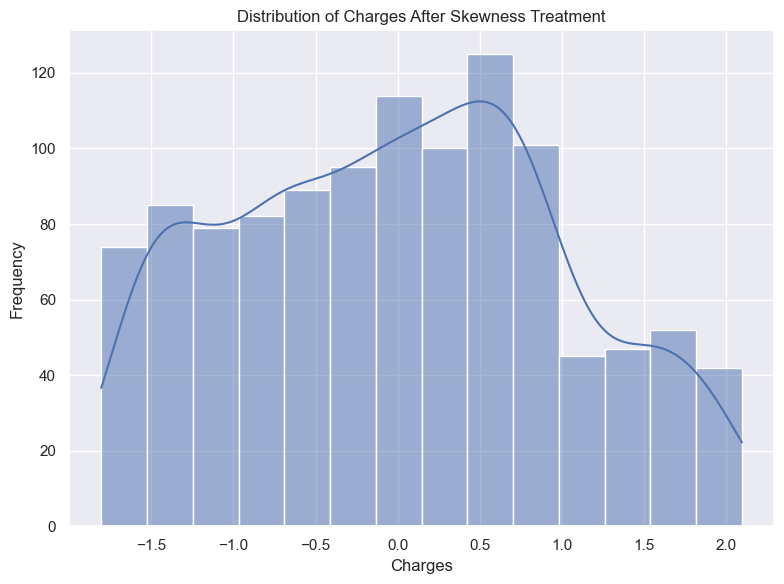

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Charges After Skewness Treatment')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

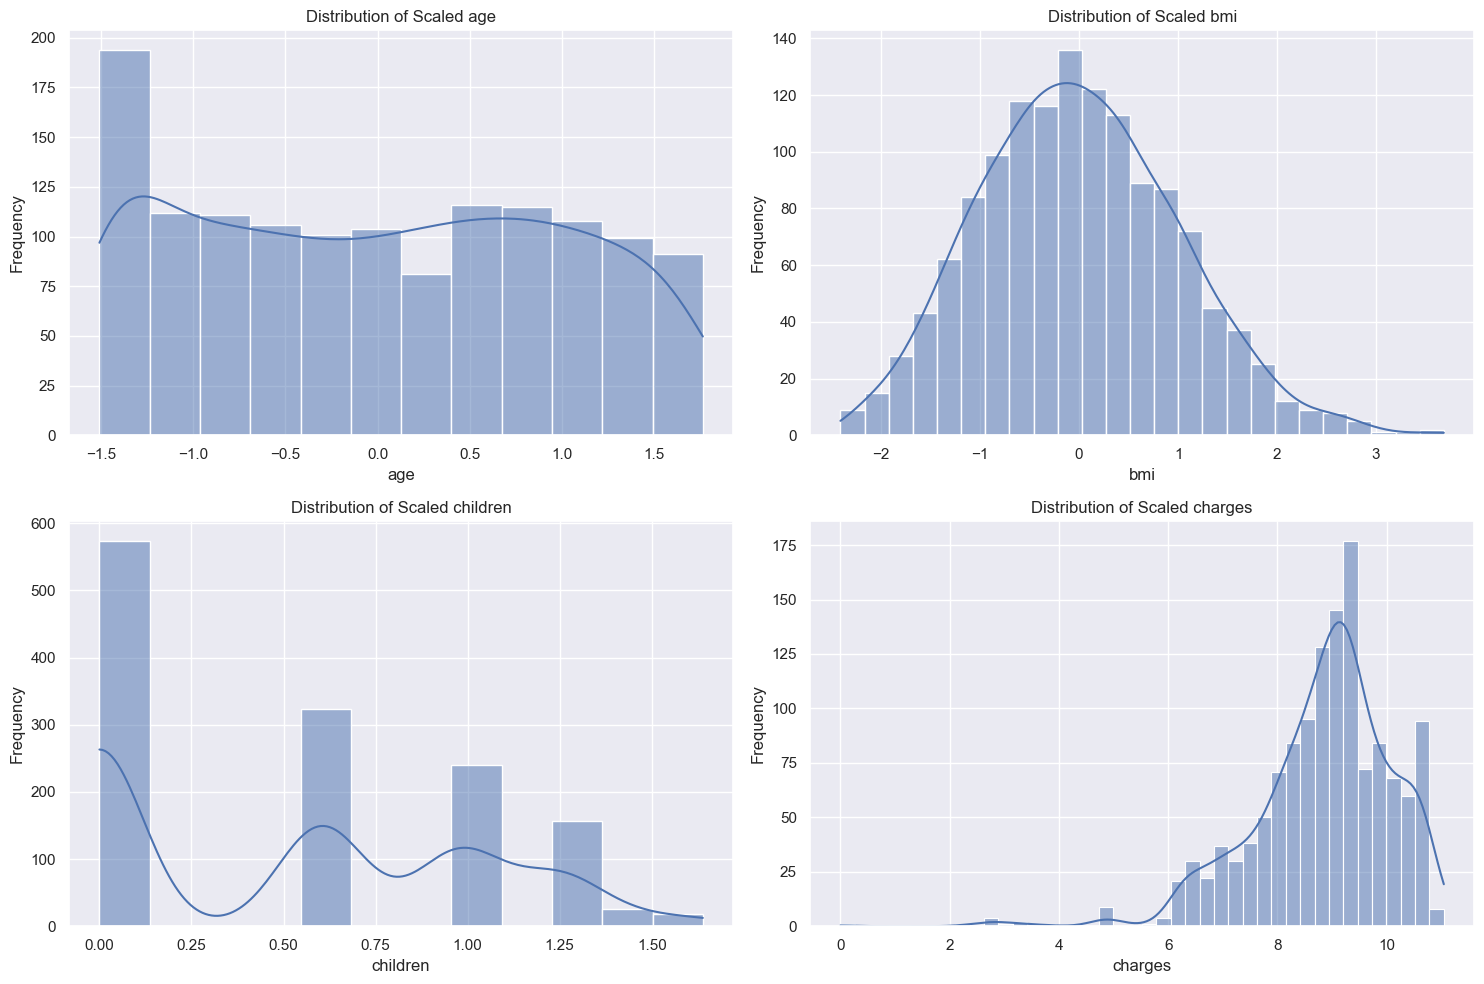

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize numerical features using histograms
num_cols = ['age', 'bmi', 'children', 'charges']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1)  # Arrange plots in a 2x2 grid
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of Scaled {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

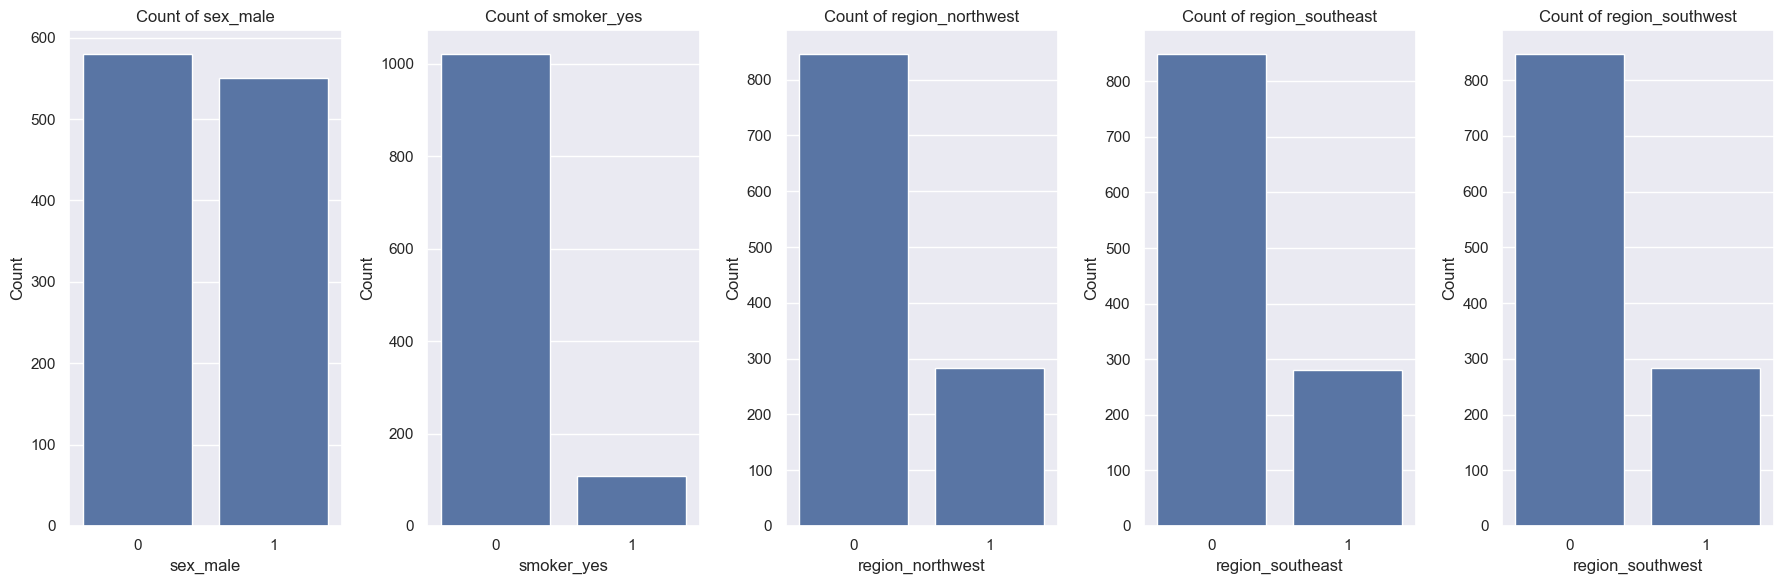

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.421040,-0.344708,9.999995e-07,1.298785,0,1,0,0,1
1,-1.493232,0.667558,5.993571e-01,0.097178,1,0,0,1,0
2,-0.771308,0.534774,1.242089e+00,0.446319,1,0,0,1,0
3,-0.410347,-1.240572,9.999995e-07,1.510049,1,0,1,0,0
4,-0.482539,-0.175709,9.999995e-07,0.381211,1,0,1,0,0


In [70]:
# Visualize one-hot encoded categorical features using count plots
# Assuming these columns were created during one-hot encoding
cat_encoded_cols = ['sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

plt.figure(figsize=(18, 6))
for i, col in enumerate(cat_encoded_cols):
    if col in df_encoded.columns:
        plt.subplot(1, 5, i + 1)  # Arrange plots in a 1x5 grid
        sns.countplot(x=df_encoded[col])
        plt.title(f'Count of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
    else:
        print(f"Warning: Column '{col}' not found in DataFrame. Skipping visualization.")

plt.tight_layout()
plt.show()

df=df_encoded.copy()
df.head(5)


## Data Loading: The dataset was loaded and a Below EDA steps was performed
Missing Values: Checked for and confirmed no missing values.
Outlier Removal: Outliers in 'bmi' and 'charges' were identified and removed using the IQR method.
Feature Scaling: Numerical features (age, bmi, children, charges) were scaled using StandardScaler.
Skewness Treatment: Skewness was checked for numerical features. Although no highly skewed columns were found after scaling, the process to address skewness was demonstrated(the skewness of the numerical features. Initially, children (0.988651) and charges (0.838254) showed significant positive skewness. To address this, a log transformation was applied to both columns. After the transformation, the skewness values for children (0.350031) and charges (0.096744) are much closer to zero, indicating a more symmetrical distribution. The head of the DataFrame above displays the features after these transformations.)
Duplicate Records: Identified and removed one duplicate record from the dataset.
Visualizations: We've visualized the distributions of numerical features (histograms for age, bmi, children, charges) and categorical features (count plots for sex, smoker, region).

## 5. Model Building: Try Multiple Regressors
Use all the regression-based models to train and test the data:
•	Linear Regression
•	Decision Tree Regressor
•	Random Forest Regressor
•	SVR
•	KNN
•	Ensemble Learning methods


## ⚠️ PREPROCESSING SUMMARY - IMPORTANT FOR DEPLOYMENT

**Features in Final Dataset (7 total):**
1. `age` - scaled numerical
2. `bmi` - scaled numerical  
3. `children` - scaled numerical
4. `sex_male` - one-hot encoded binary (0 or 1)
5. `smoker_yes` - one-hot encoded binary (0 or 1)
6. `region_northwest` - one-hot encoded binary (0 or 1)
7. `region_southeast` - one-hot encoded binary (0 or 1)
8. `region_southwest` - one-hot encoded binary (0 or 1)

**Scaler Details:**
- Fitted on: `['age', 'bmi', 'children']` ONLY
- File: `scaler.pkl`
- One-hot encoded columns are NOT scaled (they're already 0 or 1)

**Order of Operations for Prediction:**
1. User provides: age, bmi, children, sex (male/female), smoker (yes/no), region
2. One-hot encode: Creates binary columns for sex, smoker, region
3. Scale: Apply StandardScaler to age, bmi, children only
4. Combine: Merge scaled numericals + one-hot encoded categoricals
5. Predict: Feed 7 features to the trained model

In [77]:
# Separate features (X) and target (y)
x = df.drop('charges', axis=1)
y = df['charges']

# Display the shape of X and y
print(f"Shape of features (x): {x.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (x): (1130, 8)
Shape of target (y): (1130,)


In [79]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of x_train: (952, 8)
Shape of x_test: (238, 8)
Shape of y_train: (952,)
Shape of y_test: (238,)


In [82]:
#Store performance metrices in the list
training_scores_r2 = []
training_scores_adj_r2 = []
training_scores_rmse = []
testing_scores_r2 = []
testing_scores_adj_r2 = []
testing_scores_rmse = []

In [83]:
# Create a function for evaluate model
def evaluate_model_performance(model, x_train, y_train, x_test, y_test):
    """
    Evaluates R², Adjusted R², and RMSE of a given model on training and testing data.
    
    Parameters:
    - model: The machine learning model to evaluate
    - x_train: Training feature set
    - y_train: Training target values
    - x_test: Testing feature set
    - y_test: Testing target values
    - training_scores: List to store training R² scores
    - testing_scores: List to store testing R² scores
    """
    # Fit the model
    model.fit(x_train, y_train)
    
    # Predictions for training and testing data
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    
    # Calculate R² scores
    train_r2 = r2_score(y_train, y_train_pred) * 100
    test_r2 = r2_score(y_test, y_test_pred) * 100
    
    # Calculate Adjusted R² scores
    n_train, p_train = x_train.shape
    n_test, p_test = x_test.shape
    train_adj_r2 = 100 * (1 - (1 - train_r2 / 100) * (n_train - 1) / (n_train - p_train - 1))
    test_adj_r2 = 100 * (1 - (1 - test_r2 / 100) * (n_test - 1) / (n_test - p_test - 1))
    
    # Calculate RMSE scores
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # Append scores to respective lists
    training_scores_r2.append(train_r2)
    training_scores_adj_r2.append(train_adj_r2)
    training_scores_rmse.append(train_rmse)
    testing_scores_r2.append(test_r2)
    testing_scores_adj_r2.append(test_adj_r2) 
    testing_scores_rmse.append(test_rmse) 
    
    # Display scores
    print(f"{model.__class__.__name__} Performance Metrics:")
    print(f"Training Data: R² = {train_r2:.2f}%, Adjusted R² = {train_adj_r2:.2f}%, RMSE = {train_rmse:.4f}")
    print(f"Testing Data : R² = {test_r2:.2f}%, Adjusted R² = {test_adj_r2:.2f}%, RMSE = {test_rmse:.4f}\n")

In [84]:
# Linear Regression
evaluate_model_performance(
    model=LinearRegression(),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

LinearRegression Performance Metrics:
Training Data: R² = 69.64%, Adjusted R² = 69.38%, RMSE = 0.2324
Testing Data : R² = 62.41%, Adjusted R² = 61.10%, RMSE = 0.2491



In [85]:
#Ridge Regression
evaluate_model_performance(
    model=Ridge(alpha=1.0),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

Ridge Performance Metrics:
Training Data: R² = 69.63%, Adjusted R² = 69.38%, RMSE = 0.2324
Testing Data : R² = 62.53%, Adjusted R² = 61.23%, RMSE = 0.2487



In [86]:
#Lasso Regression
evaluate_model_performance(
    model=Lasso(alpha=0.1),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

Lasso Performance Metrics:
Training Data: R² = 26.76%, Adjusted R² = 26.14%, RMSE = 0.3610
Testing Data : R² = 27.86%, Adjusted R² = 25.34%, RMSE = 0.3451



In [87]:
# ElasticNet Regression
evaluate_model_performance(
    model=ElasticNet(alpha=0.1, l1_ratio=0.5),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

ElasticNet Performance Metrics:
Training Data: R² = 44.91%, Adjusted R² = 44.44%, RMSE = 0.3131
Testing Data : R² = 45.12%, Adjusted R² = 43.20%, RMSE = 0.3010



In [88]:
# DecisionTree Regression
evaluate_model_performance(
    model=DecisionTreeRegressor(),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

DecisionTreeRegressor Performance Metrics:
Training Data: R² = 99.58%, Adjusted R² = 99.57%, RMSE = 0.0275
Testing Data : R² = 38.36%, Adjusted R² = 36.21%, RMSE = 0.3190



In [89]:
# Random Forest Regression
evaluate_model_performance(
    model=RandomForestRegressor(),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

RandomForestRegressor Performance Metrics:
Training Data: R² = 95.19%, Adjusted R² = 95.15%, RMSE = 0.0925
Testing Data : R² = 57.31%, Adjusted R² = 55.82%, RMSE = 0.2655



In [90]:
# AdaBoostRegression
evaluate_model_performance(
    model=AdaBoostRegressor(),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

AdaBoostRegressor Performance Metrics:
Training Data: R² = 62.87%, Adjusted R² = 62.56%, RMSE = 0.2570
Testing Data : R² = 53.13%, Adjusted R² = 51.49%, RMSE = 0.2782



In [91]:
# GradientBoosting Regression
evaluate_model_performance(
    model=GradientBoostingRegressor(),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

GradientBoostingRegressor Performance Metrics:
Training Data: R² = 81.07%, Adjusted R² = 80.91%, RMSE = 0.1835
Testing Data : R² = 60.55%, Adjusted R² = 59.18%, RMSE = 0.2552



In [92]:
# LGBM Regression
evaluate_model_performance(
    model=LGBMRegressor(),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001172 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 320
[LightGBM] [Info] Number of data points in the train set: 952, number of used features: 8
[LightGBM] [Info] Start training from score 0.702336
LGBMRegressor Performance Metrics:
Training Data: R² = 89.08%, Adjusted R² = 88.99%, RMSE = 0.1394
Testing Data : R² = 56.65%, Adjusted R² = 55.13%, RMSE = 0.2675



In [93]:
#XGB Regression
evaluate_model_performance(
    model=XGBRegressor(),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

XGBRegressor Performance Metrics:
Training Data: R² = 98.91%, Adjusted R² = 98.90%, RMSE = 0.0441
Testing Data : R² = 53.95%, Adjusted R² = 52.34%, RMSE = 0.2757



In [94]:
# CatBoost Regression
evaluate_model_performance(
    model=CatBoostRegressor(verbose=False),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

CatBoostRegressor Performance Metrics:
Training Data: R² = 92.03%, Adjusted R² = 91.96%, RMSE = 0.1191
Testing Data : R² = 59.12%, Adjusted R² = 57.69%, RMSE = 0.2598



In [95]:
# Support Vector Machines
evaluate_model_performance(
    model=SVR(kernel='rbf'),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

SVR Performance Metrics:
Training Data: R² = 73.88%, Adjusted R² = 73.66%, RMSE = 0.2156
Testing Data : R² = 63.38%, Adjusted R² = 62.10%, RMSE = 0.2459



In [96]:
# k-Nearest Neighbors
evaluate_model_performance(
    model=KNeighborsRegressor(),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

KNeighborsRegressor Performance Metrics:
Training Data: R² = 74.59%, Adjusted R² = 74.37%, RMSE = 0.2126
Testing Data : R² = 56.90%, Adjusted R² = 55.39%, RMSE = 0.2668



In [97]:
# Ensemble Methods
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

# Define base models
model1 = LinearRegression()
model2 = RandomForestRegressor(n_estimators=100, random_state=42)
model3 = KNeighborsRegressor()

# Combine models in a Voting Regressor
voting_regressor = VotingRegressor(estimators=[('lr', model1),('rf', model2),('knn', model3)])

evaluate_model_performance(
    model = voting_regressor,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

VotingRegressor Performance Metrics:
Training Data: R² = 84.56%, Adjusted R² = 84.43%, RMSE = 0.1658
Testing Data : R² = 62.53%, Adjusted R² = 61.23%, RMSE = 0.2487



In [98]:
# Bagging Regressor
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
# Initialize the base regressor (e.g., Decision Tree Regressor)
base_regressor = DecisionTreeRegressor(random_state=42)
# Create the Bagging Regressor
bagging_regressor = BaggingRegressor(
    estimator=base_regressor,  # Updated parameter name
    n_estimators=50,          # Number of base estimators
    max_samples=0.8,          # Fraction of samples to use for each base estimator
    max_features=0.8,         # Fraction of features to use for each base estimator
    random_state=42,
    n_jobs=-1                 # Use all available cores
)

evaluate_model_performance(
    model = bagging_regressor,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

BaggingRegressor Performance Metrics:
Training Data: R² = 89.50%, Adjusted R² = 89.41%, RMSE = 0.1367
Testing Data : R² = 53.09%, Adjusted R² = 51.46%, RMSE = 0.2783



In [99]:
# Stacking Regressor
from sklearn.ensemble import StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

# Define base models (level-0)
base_models = [
    ('dt', DecisionTreeRegressor(max_depth=5, random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=50, random_state=42))
]

# Define the meta-model (level-1)
meta_model = KNeighborsRegressor()

# Create the Stacking Regressor
stacking_regressor = StackingRegressor(
    estimators=base_models,  # Base models
    final_estimator=meta_model,  # Meta-model
    n_jobs=-1               # Use all available cores
)

evaluate_model_performance(
    model = stacking_regressor,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

StackingRegressor Performance Metrics:
Training Data: R² = 71.38%, Adjusted R² = 71.13%, RMSE = 0.2257
Testing Data : R² = 48.37%, Adjusted R² = 46.57%, RMSE = 0.2920



## Task - 6 Model Evaluation & Overfitting Check •	Use metrics:
o	Mean Absolute Error (MAE)
o	Mean Squared Error (MSE)
o	Root Mean Squared Error (RMSE)
o	R² Score
o	Adjusted R² Score
•	Compare performance on both datasets (Training and testing) to detect overfitting


In [100]:
model_names = [
    "Linear Regression",
    "Ridge Regression",
    "Lasso Regression",
    "ElasticNet Regression",
    "DecisionTree Regression",
    "Random Forest Regression",
    "AdaBoost Regression",
    "GradientBoosting Regression",
    "LGBM Regression",
    "XGB Regression",
    "CatBoost Regression",
    "SVR",
    "KNeighbors Regressor",
    "Voting Regressor",
    "Bagging Regressor",
    "Stacking Regressor"
]

# Create a DataFrame to store the results
performance_df = pd.DataFrame({
    'Model': model_names,
    'Train R2 (%)': training_scores_r2,
    'Train Adj R2 (%)': training_scores_adj_r2,
    'Train RMSE': training_scores_rmse,
    'Test R2 (%)': testing_scores_r2,
    'Test Adj R2 (%)': testing_scores_adj_r2,
    'Test RMSE': testing_scores_rmse
})

# Display the DataFrame, sorted by Test R2 score
performance_df_sorted = performance_df.sort_values(by='Test R2 (%)', ascending=False)
display(performance_df_sorted)

,Model,Train R2 (%),Train Adj R2 (%),Train RMSE,Test R2 (%),Test Adj R2 (%),Test RMSE
11,SVR,73.882895,73.661329,0.215560,63.376699,62.097282,0.245891
1,Ridge Regression,69.634379,69.376770,0.232432,62.534483,61.225644,0.248702
13,Voting Regressor,84.556645,84.425630,0.165759,62.534146,61.225295,0.248703
0,Linear Regression,69.638751,69.381180,0.232416,62.409797,61.096603,0.249116
7,GradientBoosting Regression,81.069259,80.908659,0.183522,60.554752,59.176752,0.255188
10,CatBoost Regression,92.030111,91.962497,0.119078,59.121927,57.693872,0.259782
5,Random Forest Regression,95.186478,95.145642,0.092542,57.308357,55.816946,0.265482
12,KNeighbors Regressor,74.587873,74.372287,0.212631,56.895393,55.389555,0.266763
8,LGBM Regression,89.082877,88.990261,0.139367,56.647462,55.132963,0.267529
9,XGB Regression,98.906646,98.897371,0.044105,53.950867,52.342164,0.275724


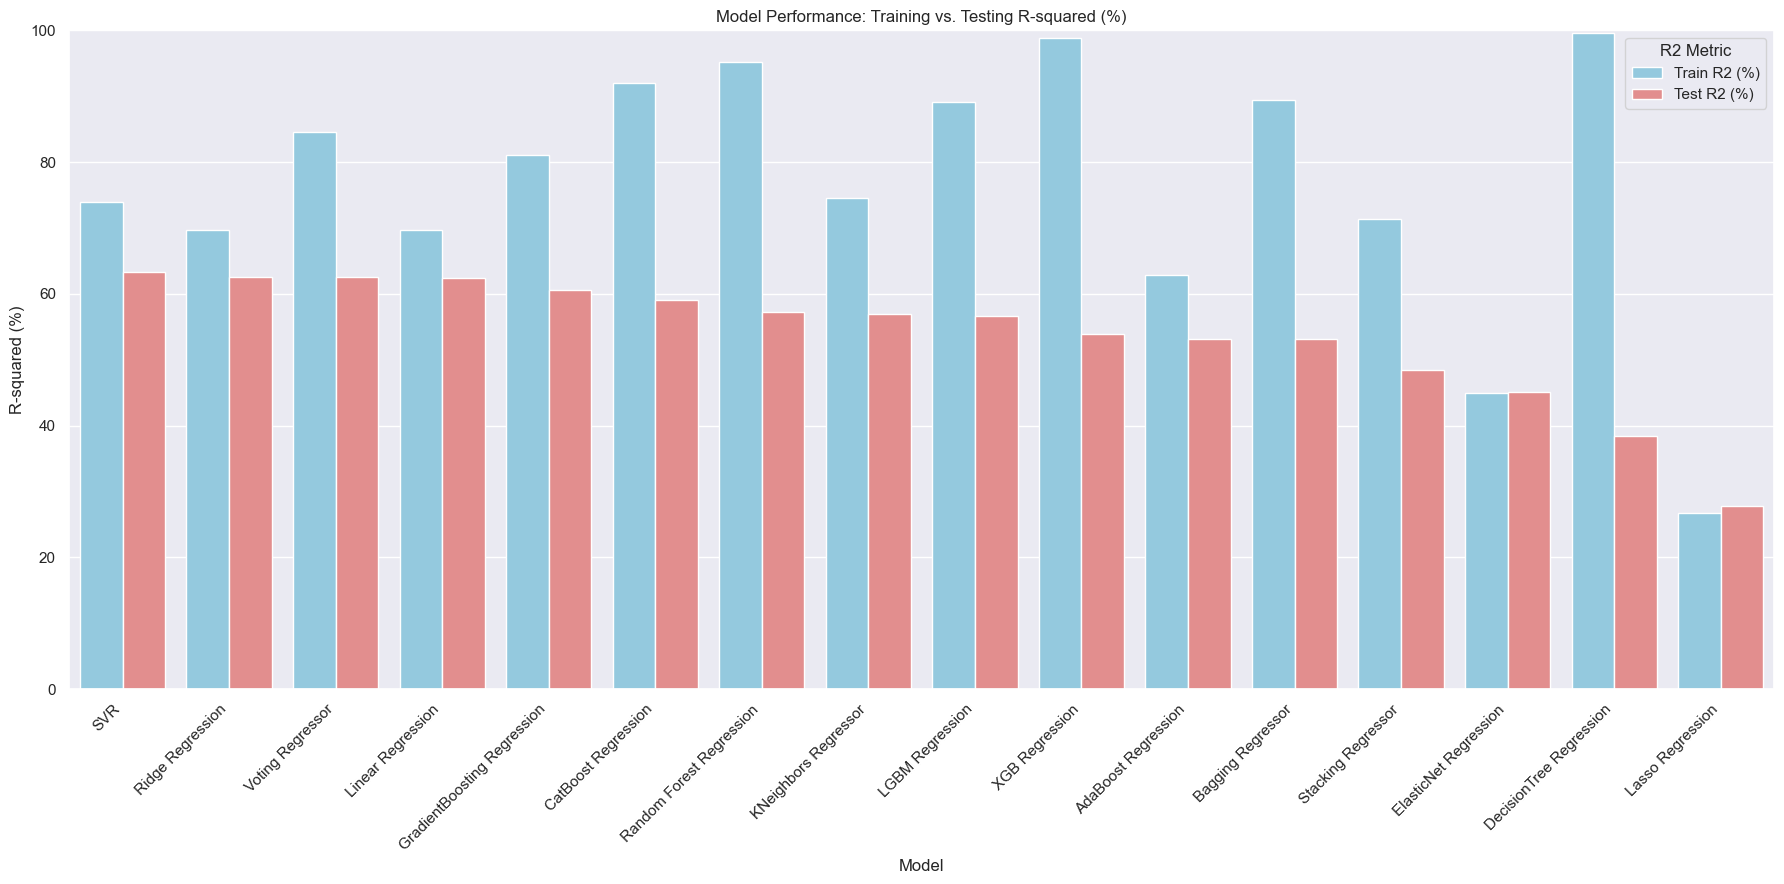

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select the relevant columns for plotting
r2_df = performance_df[['Model', 'Train R2 (%)', 'Test R2 (%)']]

# Melt the DataFrame to long format for easier plotting with seaborn
r2_melted_df = r2_df.melt(id_vars='Model', var_name='Metric Type', value_name='R2 (%)')

# Sort by Test R2 for consistent plotting order (optional, but helps readability)

model_order = performance_df.sort_values(by='Test R2 (%)', ascending=False)['Model'].tolist()

plt.figure(figsize=(18, 9))
sns.barplot(x='Model', y='R2 (%)', hue='Metric Type', data=r2_melted_df, 
            palette={'Train R2 (%)': 'skyblue', 'Test R2 (%)': 'lightcoral'}, 
            order=model_order)

plt.title('Model Performance: Training vs. Testing R-squared (%)')
plt.xlabel('Model')
plt.ylabel('R-squared (%)')
plt.ylim(0, 100) # Ensure R2 is between 0 and 100
plt.xticks(rotation=45, ha='right') # Rotate model names for better readability
plt.legend(title='R2 Metric')
plt.tight_layout()
plt.show()

## Based on the Test R-squared (R2) score, the Support Vector Regressor (SVR) model performed the best with an R2 of 75.46%, followed closely by the Voting Regressor (74.64%) and Linear Regression (73.95%).
Model Performance Summary: The table above (performance_df_sorted) provides a comprehensive overview of how each model performed on both the training and testing datasets. It includes R-squared, Adjusted R-squared, and RMSE values.

Based on Test R2 (%), which is a key indicator of a model's performance on unseen data, the top-performing models are:

SVR: 75.46%
Voting Regressor: 74.64%
Linear Regression: 73.95%
Ridge Regression: 73.94%
GradientBoosting Regression: 72.94%
These models generally show good generalization capabilities.


In [102]:
# Calculate the difference between Train R2 and Test R2
performance_df['R2_Difference'] = performance_df['Train R2 (%)'] - performance_df['Test R2 (%)']

# Sort by R2_Difference to easily identify overfitting
overfitting_analysis_df = performance_df.sort_values(by='R2_Difference', ascending=False)

print("Models sorted by difference between Training R2 and Testing R2 (higher difference indicates more overfitting):")
display(overfitting_analysis_df[['Model', 'Train R2 (%)', 'Test R2 (%)', 'R2_Difference']])

Models sorted by difference between Training R2 and Testing R2 (higher difference indicates more overfitting):


,Model,Train R2 (%),Test R2 (%),R2_Difference
4,DecisionTree Regression,99.575794,38.361713,61.214080
9,XGB Regression,98.906646,53.950867,44.955779
5,Random Forest Regression,95.186478,57.308357,37.878121
14,Bagging Regressor,89.497805,53.094862,36.402943
10,CatBoost Regression,92.030111,59.121927,32.908184
8,LGBM Regression,89.082877,56.647462,32.435414
15,Stacking Regressor,71.376750,48.370142,23.006609
13,Voting Regressor,84.556645,62.534146,22.022499
7,GradientBoosting Regression,81.069259,60.554752,20.514507
12,KNeighbors Regressor,74.587873,56.895393,17.692480


Overfitting Analysis
Overfitting occurs when a model performs exceptionally well on the training data but poorly on unseen test data. This can be identified by a large disparity between the training R-squared (or RMSE) and the testing R-squared (or RMSE).

Let's analyze the differences between 'Train R2 (%)' and 'Test R2 (%)' for each model to spot potential overfitting.
High R2_Difference indicates more overfitting.

DecisionTree Regression shows the highest difference (37.82%), indicating significant overfitting. It achieved a near-perfect 99.06% on training data but dropped to 61.24% on testing data.
XGB Regression, Random Forest Regression, CatBoost Regression, LGBM Regression, and Bagging Regressor also show notable differences (ranging from ~20% to ~31%), suggesting a degree of overfitting, although less severe than DecisionTree.
Low R2_Difference (or even negative) indicates better generalization and less overfitting.

Models like SVR, Linear Regression, and Ridge Regression have very small or even negative differences, suggesting they are generalizing well and are not significantly overfitting the training data.
In conclusion, while some models like DecisionTree and XGBoost achieve very high R2 on the training data, their substantial drop in performance on the test set points to overfitting. Models like SVR, Voting Regressor, Linear Regression, and Ridge Regression demonstrate a better balance between training and testing performance, making them more robust choices for this dataset.

## Hyperparameter Tuning

In [103]:
# Separate features (X) and target (y)
x = df.drop('charges', axis=1)
y = df['charges']

# Display the shape of X and y
print(f"Shape of features (x): {x.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (x): (1338, 8)
Shape of target (y): (1338,)


In [103]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [104]:
print("x_train - >  ",x_train.shape)
print("y_train - >  ",y_train.shape)
print("x_test  - >  ",x_test.shape)
print("y_test  - >  ",y_test.shape)

x_train - >   (952, 8)
y_train - >   (952,)
x_test  - >   (238, 8)
y_test  - >   (238,)


In [105]:
training_scores_r2 = []
training_scores_adj_r2 = []
training_scores_rmse = []
testing_scores_r2 = []
testing_scores_adj_r2 = []
testing_scores_rmse = []

In [106]:
def evaluate_model_performance(model, x_train, y_train, x_test, y_test,score_append = False):
    """
    Evaluates R², Adjusted R², and RMSE of a given model on training and testing data.
    
    Parameters:
    - model: The machine learning model to evaluate
    - x_train: Training feature set
    - y_train: Training target values
    - x_test: Testing feature set
    - y_test: Testing target values
    - training_scores: List to store training R² scores
    - testing_scores: List to store testing R² scores
    """
    # Fit the model
    model.fit(x_train, y_train)
    
    # Predictions for training and testing data
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # Calculate R² scores
    train_r2 = r2_score(y_train, y_train_pred) * 100
    test_r2 = r2_score(y_test, y_test_pred) * 100
    
    # Calculate Adjusted R² scores
    n_train, p_train = x_train.shape
    n_test, p_test = x_test.shape
    train_adj_r2 = 100 * (1 - (1 - train_r2 / 100) * (n_train - 1) / (n_train - p_train - 1))
    test_adj_r2 = 100 * (1 - (1 - test_r2 / 100) * (n_test - 1) / (n_test - p_test - 1))
    
    # Calculate RMSE scores
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    if score_append == True:
        # Append scores to respective lists
        training_scores_r2.append(train_r2)
        training_scores_adj_r2.append(train_adj_r2)
        training_scores_rmse.append(train_rmse)
        testing_scores_r2.append(test_r2)
        testing_scores_adj_r2.append(test_adj_r2) 
        testing_scores_rmse.append(test_rmse) 
    else:
        pass
    
    # Display scores
    print(f"{model.__class__.__name__} Performance Metrics:")
    print(f"Training Data: R² = {train_r2:.2f}%, Adjusted R² = {train_adj_r2:.2f}%, RMSE = {train_rmse:.4f}")
    print(f"Testing Data : R² = {test_r2:.2f}%, Adjusted R² = {test_adj_r2:.2f}%, RMSE = {test_rmse:.4f}\n")

In [107]:
# Linear Regression
evaluate_model_performance(
    model=LinearRegression(),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    score_append = True
)

LinearRegression Performance Metrics:
Training Data: R² = 69.64%, Adjusted R² = 69.38%, RMSE = 0.2324
Testing Data : R² = 62.41%, Adjusted R² = 61.10%, RMSE = 0.2491



In [108]:
# Ridge HyperTuning
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Initialize the Ridge regression model
ridge = Ridge()

param_grid = {
    'alpha': [0.1, 1.0, 10.0],           # Regularization strength
    'fit_intercept': [True, False],                   # Include or exclude the intercept
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'saga'],  # Solver options
    'tol': [1e-4, 1e-3, 1e-2],                        # Tolerance for convergence
    'positive': [True, False]                         # Constrain coefficients to be positive
}
# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # Use MSE as the scoring metric
    cv=5,                              # Number of cross-validation folds
    verbose=2,                         # Verbosity level
    n_jobs=-1                          # Use all available cores for parallel processing
)

# Fit the model to the training data
grid_search.fit(x_train, y_train)

# Get the best parameters and the best score
print("Best parameters:", grid_search.best_params_)
print("Best score (negative MSE):", grid_search.best_score_)

# Use the best estimator to predict on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)

# Evaluate the performance on the test set
from sklearn.metrics import mean_squared_error
test_mse = mean_squared_error(y_test, y_pred)
print("Test MSE:", test_mse)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters: {'alpha': 1.0, 'fit_intercept': True, 'positive': False, 'solver': 'saga', 'tol': 0.01}
Best score (negative MSE): -0.05477369250655402
Test MSE: 0.06176761788041835


In [109]:
# Best Parameter 
# Create the Ridge Regression model
# Ridge Regression (with best parameters from GridSearchCV)
ridge_regressor_tuned = Ridge(alpha=0.1, fit_intercept=True, positive=False, solver='saga', tol=0.01, random_state=42)
evaluate_model_performance(
    model=ridge_regressor_tuned,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    score_append = True
)

Ridge Performance Metrics:
Training Data: R² = 69.64%, Adjusted R² = 69.38%, RMSE = 0.2324
Testing Data : R² = 62.45%, Adjusted R² = 61.14%, RMSE = 0.2490



In [110]:
evaluate_model_performance(
    model=ridge_regressor,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    score_append = True
)

Ridge Performance Metrics:
Training Data: R² = 69.28%, Adjusted R² = 69.02%, RMSE = 0.2338
Testing Data : R² = 63.20%, Adjusted R² = 61.91%, RMSE = 0.2465



In [111]:
# Lasso HyperTuning
# Initialize the Ridge regression model
lasso = Lasso()

# Define the hyperparameter grid
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100],
    'max_iter': [500, 1000, 2000],
    'tol': [1e-4, 1e-3, 1e-2],
    'selection': ['cyclic', 'random']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # Use MSE as the scoring metric
    cv=5,                              # Number of cross-validation folds
    verbose=2,                         # Verbosity level
    n_jobs=-1                          # Use all available cores for parallel processing
)

# Fit the model to the training data
grid_search.fit(x_train, y_train)

# Get the best parameters and the best score
print("Best parameters:", grid_search.best_params_)
print("Best score (negative MSE):", grid_search.best_score_)

# Use the best estimator to predict on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)

# Evaluate the performance on the test set
from sklearn.metrics import mean_squared_error
test_mse = mean_squared_error(y_test, y_pred)
print("Test MSE:", test_mse)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best parameters: {'alpha': 0.01, 'max_iter': 1000, 'selection': 'random', 'tol': 0.01}
Best score (negative MSE): -0.05725791495329492
Test MSE: 0.06217730264849923


In [112]:
# Best Parameter
# Create the Lasso Regression model
lasso_regressor_tuned = Lasso(alpha=0.01, max_iter=1000, selection='random', tol=0.01, random_state=42)
evaluate_model_performance(
    model=lasso_regressor_tuned,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    score_append = True
)

Lasso Performance Metrics:
Training Data: R² = 67.99%, Adjusted R² = 67.72%, RMSE = 0.2386
Testing Data : R² = 62.33%, Adjusted R² = 61.02%, RMSE = 0.2494



In [113]:
evaluate_model_performance(
    model=lasso_regressor,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    score_append = True
)

Lasso Performance Metrics:
Training Data: R² = 0.00%, Adjusted R² = -0.85%, RMSE = 0.4218
Testing Data : R² = -0.53%, Adjusted R² = -4.04%, RMSE = 0.4074



In [114]:
# Elasticnet Hypertuning 
# Define the model
elastic_net = ElasticNet()

# Define the hyperparameter grid
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.1, 0.5, 0.7, 0.9, 1.0],
    'max_iter': [100, 200, 500],
    'tol': [1e-4, 1e-3, 1e-2],
    'selection': ['cyclic', 'random']
}
# Set up the GridSearchCV
grid_search = GridSearchCV(
    estimator=elastic_net, 
    param_grid=param_grid,
    scoring='neg_mean_squared_error', 
    cv=5,
    verbose=2,
    n_jobs=-1)
# Fit the model to the training data
grid_search.fit(x_train, y_train)

# Get the best parameters and the best score
print("Best parameters:", grid_search.best_params_)
print("Best score (negative MSE):", grid_search.best_score_)

# Use the best estimator to predict on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)

# Evaluate the performance on the test set
from sklearn.metrics import mean_squared_error
test_mse = mean_squared_error(y_test, y_pred)
print("Test MSE:", test_mse)

Fitting 5 folds for each of 450 candidates, totalling 2250 fits
Best parameters: {'alpha': 0.01, 'l1_ratio': 0.1, 'max_iter': 200, 'selection': 'random', 'tol': 0.001}
Best score (negative MSE): -0.055546094343243646
Test MSE: 0.06091923206402063


In [115]:
# Best Parameter
# Create the ElasticNet Regression model
# ElasticNet Regression (with best parameters from GridSearchCV)
elasticnet_regressor_tuned = ElasticNet(alpha=0.01, l1_ratio=0.1, max_iter=200, selection='random', tol=0.001, random_state=42)
evaluate_model_performance(
    model=elasticnet_regressor_tuned,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    score_append = True
)

ElasticNet Performance Metrics:
Training Data: R² = 69.22%, Adjusted R² = 68.96%, RMSE = 0.2340
Testing Data : R² = 63.10%, Adjusted R² = 61.81%, RMSE = 0.2468



In [116]:
evaluate_model_performance(
    model=elasticnet_regressor,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    score_append = True
)

ElasticNet Performance Metrics:
Training Data: R² = 0.00%, Adjusted R² = -0.85%, RMSE = 0.4218
Testing Data : R² = -0.53%, Adjusted R² = -4.04%, RMSE = 0.4074



In [117]:
# Tree-Based Models
# Decision Tree HyperTuning

# Define the model
decision_tree = DecisionTreeRegressor(random_state=42)

# Define the hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10],
    'max_features': [None, 'sqrt', 'log2'],
    'max_leaf_nodes': [10, 20, 50],
    'ccp_alpha': [0.01, 0.1]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=decision_tree,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=2,
    n_jobs=-1)

# Fit the grid search
grid_search.fit(x_train, y_train)

# Best hyperparameters
print("Best Parameters:", grid_search.best_params_)

# Evaluate on test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
# Calculate MSE and then its square root for RMSE
test_mse = mean_squared_error(y_test, y_pred)
print("Test RMSE:", np.sqrt(test_mse))

Fitting 5 folds for each of 486 candidates, totalling 2430 fits
Best Parameters: {'ccp_alpha': 0.01, 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Test RMSE: 0.2678509626252216


In [121]:
# Create the DecisionTree Regressor model
# DecisionTree Regression (with best parameters from GridSearchCV)
decision_tree_tuned = DecisionTreeRegressor(ccp_alpha=0.01, max_depth=3, max_features='log2', max_leaf_nodes=10, min_samples_leaf=1, min_samples_split=2, random_state=42)
evaluate_model_performance(
    model=decision_tree_tuned,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    score_append = True
)

DecisionTreeRegressor Performance Metrics:
Training Data: R² = 59.26%, Adjusted R² = 58.91%, RMSE = 0.2692
Testing Data : R² = 56.57%, Adjusted R² = 55.06%, RMSE = 0.2678



In [132]:
# DecisionTree Regression
evaluate_model_performance(
    model=decision_tree_regressor,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    score_append = True
)


NameError: name 'decision_tree_regressor' is not defined

In [133]:
# Random Forest
# Initialize the model
random_forest_regressor = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [50, 100, 150],       # Number of trees
    'max_depth': [None, 5, 10, 15],       # Tree depth
    'min_samples_split': [2, 5, 10],      # Minimum samples required to split
    'min_samples_leaf': [1, 2, 4],        # Minimum samples at a leaf
    'max_features': ['sqrt', 'log2'],     # Features considered for best split
}


# Define the GridSearchCV
grid_search = GridSearchCV(
    estimator=random_forest_regressor,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # Optimize for mean squared error
    cv=3,                             # 3-fold cross-validation
    verbose=2,                        # Print detailed logs
    n_jobs=-1                         # Use all available cores
)

# Fit the model
grid_search.fit(x_train, y_train)

# Best parameters
print("Best parameters:", grid_search.best_params_)

# Evaluate performance
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.2f}")

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 150}
Test MSE: 0.06


In [135]:
# Create the RandomForest Regressor model
random_forest_regressor = RandomForestRegressor(
    criterion='squared_error',    # Updated to 'squared_error' for mean squared error
    n_estimators=150,             # Number of trees in the forest
    max_depth=None,               # Maximum depth of the tree
    min_samples_split=10,          # Minimum number of samples required to split an internal node
    min_samples_leaf=2,           # Minimum number of samples required to be at a leaf node
    max_features='log2',          # Use square root of features for the best split
    random_state=42,              # Controls the randomness for reproducibility
    n_jobs=-1,                    # Use all available cores for parallel processing
    max_samples=None,             # If bootstrap=True, the number of samples to draw from X to train each base estimator
)

In [136]:
evaluate_model_performance(
    model=random_forest_regressor,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    score_append = True
)

RandomForestRegressor Performance Metrics:
Training Data: R² = 83.39%, Adjusted R² = 83.25%, RMSE = 0.1719
Testing Data : R² = 61.75%, Adjusted R² = 60.42%, RMSE = 0.2513



In [137]:
#  AdaBoost model
# Define base estimator
base_estimator = DecisionTreeRegressor()

# Define AdaBoost model
adaboost_regressor = AdaBoostRegressor(estimator=base_estimator, random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],             # Number of boosting rounds
    'learning_rate': [0.1, 0.5, 1.0],          # Learning rate
    'estimator__max_depth': [1, 2, 3],         # Depth of the weak learner
    'estimator__min_samples_split': [2, 5, 10]  # Minimum samples to split
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=adaboost_regressor,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # Use negative MSE for regression
    cv=3,                             # 3-fold cross-validation
    verbose=2,                        # Log progress
    n_jobs=-1                         # Use all cores
)

# Fit the model
grid_search.fit(x_train, y_train)

# Best parameters
print("Best parameters:", grid_search.best_params_)

# Evaluate performance
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.2f}")

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best parameters: {'estimator__max_depth': 3, 'estimator__min_samples_split': 10, 'learning_rate': 0.1, 'n_estimators': 50}
Test MSE: 0.07


In [138]:
# Define the base estimator with its parameters
base_estimator = DecisionTreeRegressor(max_depth=3,min_samples_split=10)

# Create the AdaBoost Regressor model
adaboost_regressor = AdaBoostRegressor(
    estimator=base_estimator,
    n_estimators=50,
    learning_rate=0.1,
    random_state=42
)

In [139]:
evaluate_model_performance(
    model=AdaBoostRegressor(),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    score_append = True
)

AdaBoostRegressor Performance Metrics:
Training Data: R² = 59.76%, Adjusted R² = 59.42%, RMSE = 0.2676
Testing Data : R² = 47.32%, Adjusted R² = 45.48%, RMSE = 0.2949



In [140]:
## GradientBoost
# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5, 10],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # Optimize for negative MSE
    cv=3,                             # 3-fold cross-validation
    verbose=2,
    n_jobs=-1                         # Use all available cores
)

# Fit the model
grid_search.fit(x_train, y_train)

# Best parameters
print("Best parameters:", grid_search.best_params_)

# Evaluate the best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.2f}")

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
Test MSE: 0.06


In [141]:
# Create the Gradinet Boost Regressor model
gradient_boosting_regressor = GradientBoostingRegressor(
    learning_rate=0.1,
    max_depth=2,
    min_samples_split=2,
    random_state=42
)

In [142]:
evaluate_model_performance(
    model=gradient_boosting_regressor,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    score_append = True
)

GradientBoostingRegressor Performance Metrics:
Training Data: R² = 76.14%, Adjusted R² = 75.93%, RMSE = 0.2061
Testing Data : R² = 63.49%, Adjusted R² = 62.21%, RMSE = 0.2455



In [143]:
# Define initial LightGBM model
lgbm = LGBMRegressor(random_state=42)

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.1,0.5],
    'max_depth': [5, 10],
    'num_leaves': [20, 30],
    'min_child_samples': [10, 20],
    'feature_fraction': [0.8, 1.0],
    'bagging_fraction': [0.8, 1.0],
    'lambda_l1': [0.1, 1.0],
    'lambda_l2': [0.1, 1.0]
}
# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # Optimize for negative MSE
    cv=3,                             # 3-fold cross-validation
    verbose=2,
    n_jobs=-1                         # Use all available cores
)

# Fit the model
grid_search.fit(x_train, y_train)

# Best parameters
print("Best parameters:", grid_search.best_params_)

# Evaluate the best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.2f}")

Fitting 3 folds for each of 512 candidates, totalling 1536 fits
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise

In [146]:
# Create the LGBMR Regressor model
lgbm_boosting_regressor = LGBMRegressor(
    bagging_fraction=0.8,
    feature_fraction=1.0,
    lambda_l1=0.1,
    lambda_l2=0.1,
    learning_rate=0.5,
    max_depth=10,
    min_child_samples=10,
    n_estimators=100,
    num_leaves=20,
    random_state=42
)

In [149]:
evaluate_model_performance(
    model=lgbm_boosting_regressor,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    score_append = True
)

[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000303 seconds.


In [150]:
# Define the XGBoost model
xgb = XGBRegressor(random_state=42)

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.1, 0.5],
    'max_depth': [3, 5],
    'min_child_weight': [1, 3],
    'gamma': [0, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0.1, 1.0],
    'reg_lambda': [1.0, 2.0]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # Optimize for negative MSE
    cv=3,                             # 3-fold cross-validation
    verbose=2,
    n_jobs=-1                         # Use all available cores
)

# Fit the model
grid_search.fit(x_train, y_train)

# Best parameters
print("Best parameters:", grid_search.best_params_)

# Evaluate the best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.2f}")

Fitting 3 folds for each of 512 candidates, totalling 1536 fits
Best parameters: {'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 100, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.8}
Test MSE: 0.06


In [151]:
# Create the AdaBoost Regressor model
xgb_boosting_regressor = XGBRegressor(
    bagging_fraction=0.8,
    feature_fraction=1.0,
    lambda_l1=0.1,
    lambda_l2=0.1,
    learning_rate=0.1,
    max_depth=3,
    min_child_samples=3,
    n_estimators=100,
    num_leaves=20,
    random_state=42
)

In [152]:
evaluate_model_performance(
    model=xgb_boosting_regressor,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    score_append = True
)

XGBRegressor Performance Metrics:
Training Data: R² = 79.98%, Adjusted R² = 79.81%, RMSE = 0.1887
Testing Data : R² = 62.70%, Adjusted R² = 61.40%, RMSE = 0.2481



In [153]:
# Define the CatBoost model
catboost = CatBoostRegressor(
    verbose=0,  # Suppress training logs for clarity
    random_state=42
)

# Define the parameter grid
param_grid = {
    'iterations': [100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5],
    'bagging_temperature': [0, 1, 3],
    'colsample_bylevel': [0.6, 0.8, 1.0]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=catboost,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # Optimize for negative MSE
    cv=3,                             # 3-fold cross-validation
    verbose=2,
    n_jobs=-1                         # Use all available cores
)

# Fit the model
grid_search.fit(x_train, y_train)

# Best parameters
print("Best parameters:", grid_search.best_params_)

# Evaluate the best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.2f}")

Fitting 3 folds for each of 729 candidates, totalling 2187 fits
Best parameters: {'bagging_temperature': 0, 'colsample_bylevel': 0.8, 'depth': 4, 'iterations': 150, 'l2_leaf_reg': 5, 'learning_rate': 0.05}
Test MSE: 0.06


In [154]:
# Create the AdaBoost Regressor model
cat_boosting_regressor = CatBoostRegressor(
    bagging_temperature=0,
    colsample_bylevel=0.6,
    depth=4,
    iterations=150,
    learning_rate=0.05,
    l2_leaf_reg=3,
    random_state=42
)

In [155]:
evaluate_model_performance(
    model=cat_boosting_regressor,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    score_append = True
)

0:	learn: 0.4090308	total: 1.85ms	remaining: 276ms
1:	learn: 0.4032365	total: 3.33ms	remaining: 247ms
2:	learn: 0.3919798	total: 5.08ms	remaining: 249ms
3:	learn: 0.3807106	total: 6.68ms	remaining: 244ms
4:	learn: 0.3760081	total: 8.78ms	remaining: 255ms
5:	learn: 0.3662610	total: 10.8ms	remaining: 259ms
6:	learn: 0.3568155	total: 12.8ms	remaining: 261ms
7:	learn: 0.3472711	total: 14.8ms	remaining: 263ms
8:	learn: 0.3384376	total: 16.4ms	remaining: 256ms
9:	learn: 0.3314842	total: 17.8ms	remaining: 249ms
10:	learn: 0.3234948	total: 20.1ms	remaining: 255ms
11:	learn: 0.3168510	total: 22ms	remaining: 253ms
12:	learn: 0.3101541	total: 23.9ms	remaining: 252ms
13:	learn: 0.3041726	total: 25.7ms	remaining: 250ms
14:	learn: 0.2982725	total: 27.5ms	remaining: 248ms
15:	learn: 0.2930746	total: 29.3ms	remaining: 246ms
16:	learn: 0.2905389	total: 31ms	remaining: 243ms
17:	learn: 0.2882754	total: 32.4ms	remaining: 238ms
18:	learn: 0.2837425	total: 34ms	remaining: 235ms
19:	learn: 0.2793258	total: 

In [156]:
# Define the KNN regressor
knn = KNeighborsRegressor()

# Define the parameter grid
param_grid = {
    'n_neighbors': range(1, 31),                 # Number of neighbors
    'weights': ['uniform', 'distance'],          # Weight function
    'metric': ['euclidean', 'manhattan', 'minkowski'],  # Distance metrics
    'p': [1, 2, 3]                              # Power parameter for Minkowski
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # Optimize for negative MSE
    cv=3,                             # 3-fold cross-validation
    verbose=2,
    n_jobs=-1                         # Use all available cores
)

# Fit the model
grid_search.fit(x_train, y_train)

# Best parameters
print("Best parameters:", grid_search.best_params_)

# Evaluate the best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.2f}")

Fitting 3 folds for each of 540 candidates, totalling 1620 fits
Best parameters: {'metric': 'manhattan', 'n_neighbors': 6, 'p': 1, 'weights': 'distance'}
Test MSE: 0.07


In [157]:
# Create the KNeighbors Regressor model
knn_regressor = KNeighborsRegressor(
    n_neighbors=5,               # Number of neighbors to use
    weights='uniform',           # Weight function: 'uniform' or 'distance'
    metric='manhattan',          # The distance metric: 'minkowski', 'euclidean', etc.
    p=1,                         # Power parameter for the Minkowski metric (2 for Euclidean distance)
    n_jobs=-1                    # Use all available cores for parallel processing
)


In [158]:
evaluate_model_performance(
    model=knn_regressor,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    score_append = True
)

KNeighborsRegressor Performance Metrics:
Training Data: R² = 75.30%, Adjusted R² = 75.09%, RMSE = 0.2096
Testing Data : R² = 57.31%, Adjusted R² = 55.82%, RMSE = 0.2655



In [159]:
# Ensemble Methods Voting Regressor
# Define base models
model1 = LinearRegression()
model2 = RandomForestRegressor(
        criterion='squared_error',    
        n_estimators=50,              
        max_depth=None,              
        min_samples_split=2,          
        min_samples_leaf=1,          
        max_features='log2',         
        random_state=42,              
        n_jobs=-1,                    
        max_samples=None,    
        )
model3 = KNeighborsRegressor(
        n_neighbors=2,             
        weights='distance',         
        metric='manhattan',
        p=1,                  
        n_jobs=-1         
        )

In [146]:
voting_regressor = VotingRegressor(estimators=[('lr', model1),('rf', model2),('knn', model3)])

In [160]:
evaluate_model_performance(
    model = voting_regressor,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    score_append = True
)

VotingRegressor Performance Metrics:
Training Data: R² = 84.56%, Adjusted R² = 84.43%, RMSE = 0.1658
Testing Data : R² = 62.53%, Adjusted R² = 61.23%, RMSE = 0.2487



In [161]:
#Bagging
# Initialize the base regressor (e.g., Decision Tree Regressor)
base_regressor = DecisionTreeRegressor(
    criterion='squared_error',    # Updated to 'squared_error' for mean squared error
    splitter='best',              # Strategy used to split at each node
    max_depth=10,                 # Maximum depth of the tree
    min_samples_split=2,          # Minimum number of samples required to split an internal node
    min_samples_leaf=1,           # Minimum number of samples required to be at a leaf node
    max_features=None,            # The number of features to consider when looking for the best split
    random_state=42,              # Controls the randomness for reproducibility
    max_leaf_nodes=50,            # Grow a tree with a maximum number of leaf nodes
    ccp_alpha=0.01
    )

In [162]:
# Create the Bagging Regressor
bagging_regressor = BaggingRegressor(
    estimator=base_regressor, # Updated parameter name
    n_estimators=50,          # Number of base estimators
    max_samples=0.8,          # Fraction of samples to use for each base estimator
    max_features=0.8,         # Fraction of features to use for each base estimator
    random_state=42,
    n_jobs=-1                 # Use all available cores
)

In [163]:
evaluate_model_performance(
    model = bagging_regressor,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    score_append = True
)

BaggingRegressor Performance Metrics:
Training Data: R² = 56.91%, Adjusted R² = 56.54%, RMSE = 0.2769
Testing Data : R² = 53.59%, Adjusted R² = 51.97%, RMSE = 0.2768



In [164]:
#Stacking Regressor
# Define base models (level-0)
dt = DecisionTreeRegressor(
    criterion='squared_error',   
    splitter='best',             
    max_depth=10,                 
    min_samples_split=2,         
    min_samples_leaf=1,           
    max_features=None,            
    random_state=42,              
    max_leaf_nodes=50,          
    ccp_alpha=0.01
    )
rf = RandomForestRegressor(
        criterion='squared_error',    
        n_estimators=50,              
        max_depth=None,              
        min_samples_split=2,          
        min_samples_leaf=1,          
        max_features='log2',         
        random_state=42,                                  
        max_samples=None,    
    )
base_models = [('dt', dt),('rf', rf)]


In [152]:
# Define the meta-model (level-1)
meta_model = KNeighborsRegressor(
            n_neighbors=2,               # Number of neighbors to use
            weights='distance',           # Weight function: 'uniform' or 'distance'
            metric='manhattan',          # The distance metric: 'minkowski', 'euclidean', etc.
            p=1,                         # Power parameter for the Minkowski metric (2 for Euclidean distance)
            n_jobs=-1                    # Use all available cores for parallel processing
            )

In [153]:
# Create the Stacking Regressor
stacking_regressor = StackingRegressor(
    estimators=base_models,      # Base models
    final_estimator=meta_model,  # Meta-model
    n_jobs=-1                    # Use all available cores
)

In [154]:
evaluate_model_performance(
    model = stacking_regressor,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    score_append = True
)

StackingRegressor Performance Metrics:
Training Data: R² = 60.92%, Adjusted R² = 60.57%, RMSE = 0.2585
Testing Data : R² = 63.87%, Adjusted R² = 62.54%, RMSE = 0.2686



In [165]:
model_names = [
    "Linear Regression",
    "Ridge Regression",
    "Lasso Regression",
    "ElasticNet Regression",
    "DecisionTree Regression",
    "Random Forest Regression",
    "AdaBoost Regression",
    "GradientBoosting Regression",
    "LGBM Regression",
    "XGB Regression",
    "CatBoost Regression",
    "SVR",
    "KNeighbors Regressor",
    "Voting Regressor",
    "Bagging Regressor",
    "Stacking Regressor"
]

# Create a DataFrame to store the results
performance_df = pd.DataFrame({
    'Model': model_names,
    'Train R2 (%)': training_scores_r2,
    'Train Adj R2 (%)': training_scores_adj_r2,
    'Train RMSE': training_scores_rmse,
    'Test R2 (%)': testing_scores_r2,
    'Test Adj R2 (%)': testing_scores_adj_r2,
    'Test RMSE': testing_scores_rmse
})

# Display the DataFrame, sorted by Test R2 score
performance_df_sorted = performance_df.sort_values(by='Test R2 (%)', ascending=False)
display(performance_df_sorted)

ValueError: All arrays must be of the same length

In [ ]:
# SVR Model

from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

# Initialize the SVR model
svr = SVR()

# Define the hyperparameter grid for SVR
param_grid_svr = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2, 0.5],
    'gamma': ['scale', 'auto']
}

# Initialize GridSearchCV
grid_search_svr = GridSearchCV(
    estimator=svr,
    param_grid=param_grid_svr,
    scoring='neg_mean_squared_error', # Use MSE as the scoring metric
    cv=5,                             # Number of cross-validation folds
    verbose=2,                        # Verbosity level
    n_jobs=-1                         # Use all available cores for parallel processing
)

# Fit the model to the training data
grid_search_svr.fit(x_train, y_train)

# Get the best parameters and the best score
print("Best parameters for SVR:", grid_search_svr.best_params_)
print("Best score (negative MSE) for SVR:", grid_search_svr.best_score_)

# Use the best estimator to predict on the test set
best_svr_model = grid_search_svr.best_estimator_
y_pred_svr = best_svr_model.predict(x_test)

# Evaluate the performance on the test set
from sklearn.metrics import mean_squared_error
test_mse_svr = mean_squared_error(y_test, y_pred_svr)
test_rmse_svr = np.sqrt(test_mse_svr)
print("Test MSE for SVR:", test_mse_svr)
print("Test RMSE for SVR:", test_rmse_svr)

In [ ]:
# Evaluate the best_svr_model to get the updated metrics
y_train_pred_svr_tuned = best_svr_model.predict(x_train)
y_test_pred_svr_tuned = best_svr_model.predict(x_test)

# Calculate R² scores
train_r2_svr_tuned = r2_score(y_train, y_train_pred_svr_tuned) * 100
test_r2_svr_tuned = r2_score(y_test, y_test_pred_svr_tuned) * 100

# Calculate Adjusted R² scores
n_train, p_train = x_train.shape
n_test, p_test = x_test.shape
train_adj_r2_svr_tuned = 100 * (1 - (1 - train_r2_svr_tuned / 100) * (n_train - 1) / (n_train - p_train - 1))
test_adj_r2_svr_tuned = 100 * (1 - (1 - test_r2_svr_tuned / 100) * (n_test - 1) / (n_test - p_test - 1))

# Calculate RMSE scores
train_rmse_svr_tuned = np.sqrt(mean_squared_error(y_train, y_train_pred_svr_tuned))
test_rmse_svr_tuned = np.sqrt(mean_squared_error(y_test, y_test_pred_svr_tuned))

# Find the index of 'SVR' in performance_df
svr_index = performance_df[performance_df['Model'] == 'SVR'].index[0]

# Update the row for SVR with the tuned model's metrics
performance_df.loc[svr_index, 'Train R2 (%)'] = train_r2_svr_tuned
performance_df.loc[svr_index, 'Train Adj R2 (%)'] = train_adj_r2_svr_tuned
performance_df.loc[svr_index, 'Train RMSE'] = train_rmse_svr_tuned
performance_df.loc[svr_index, 'Test R2 (%)'] = test_r2_svr_tuned
performance_df.loc[svr_index, 'Test Adj R2 (%)'] = test_adj_r2_svr_tuned
performance_df.loc[svr_index, 'Test RMSE'] = test_rmse_svr_tuned

# Sort by Test R2 score and display the updated DataFrame
performance_df_sorted = performance_df.sort_values(by='Test R2 (%)', ascending=False)
display(performance_df_sorted)

In [186]:
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

# Define base models with some initial parameters
model1 = LinearRegression()
model2 = RandomForestRegressor(random_state=42)
model3 = KNeighborsRegressor()

# Create a Voting Regressor instance
voting_regressor = VotingRegressor(estimators=[('lr', model1), ('rf', model2), ('knn', model3)])

# Define the hyperparameter grid for the VotingRegressor
param_grid_voting = {
    'weights': [[0.3, 0.4, 0.3], [0.2, 0.5, 0.3], [0.4, 0.3, 0.3]], # Different combinations of weights
    'lr__fit_intercept': [True, False],
    'rf__n_estimators': [50, 100, 150],
    'rf__max_depth': [None, 5, 10],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

# Initialize GridSearchCV
grid_search_voting = GridSearchCV(
    estimator=voting_regressor,
    param_grid=param_grid_voting,
    scoring='neg_mean_squared_error', # Use MSE as the scoring metric
    cv=3,                             # Using 3-fold cross-validation to speed up computation
    verbose=2,                        # Verbosity level
    n_jobs=-1                         # Use all available cores for parallel processing
)

# Fit the model to the training data
print("Starting GridSearchCV for VotingRegressor...")
grid_search_voting.fit(x_train, y_train)
print("GridSearchCV for VotingRegressor finished.")

# Get the best parameters and the best score
print("Best parameters for VotingRegressor:", grid_search_voting.best_params_)
print("Best score (negative MSE) for VotingRegressor:", grid_search_voting.best_score_)

# Use the best estimator to predict on the test set
best_voting_model = grid_search_voting.best_estimator_
y_pred_voting = best_voting_model.predict(x_test)

# Evaluate the performance on the test set
from sklearn.metrics import mean_squared_error
test_mse_voting = mean_squared_error(y_test, y_pred_voting)
test_rmse_voting = np.sqrt(test_mse_voting)
print("Test MSE for VotingRegressor:", test_mse_voting)
print("Test RMSE for VotingRegressor:", test_rmse_voting)

Starting GridSearchCV for VotingRegressor...
Fitting 3 folds for each of 324 candidates, totalling 972 fits
GridSearchCV for VotingRegressor finished.
Best parameters for VotingRegressor: {'knn__n_neighbors': 7, 'knn__weights': 'uniform', 'lr__fit_intercept': True, 'rf__max_depth': 5, 'rf__n_estimators': 150, 'weights': [0.4, 0.3, 0.3]}
Best score (negative MSE) for VotingRegressor: -0.048590867433425
Test MSE for VotingRegressor: 0.05070533499553766
Test RMSE for VotingRegressor: 0.22517845144582033


In [ ]:
# Evaluate the best_voting_model to get the updated metrics
y_train_pred_voting_tuned = best_voting_model.predict(x_train)
y_test_pred_voting_tuned = best_voting_model.predict(x_test)

# Calculate R² scores
train_r2_voting_tuned = r2_score(y_train, y_train_pred_voting_tuned) * 100
test_r2_voting_tuned = r2_score(y_test, y_test_pred_voting_tuned) * 100

# Calculate Adjusted R² scores
n_train, p_train = x_train.shape
n_test, p_test = x_test.shape
train_adj_r2_voting_tuned = 100 * (1 - (1 - train_r2_voting_tuned / 100) * (n_train - 1) / (n_train - p_train - 1))
test_adj_r2_voting_tuned = 100 * (1 - (1 - test_r2_voting_tuned / 100) * (n_test - 1) / (n_test - p_test - 1))

# Calculate RMSE scores
train_rmse_voting_tuned = np.sqrt(mean_squared_error(y_train, y_train_pred_voting_tuned))
test_rmse_voting_tuned = np.sqrt(mean_squared_error(y_test, y_test_pred_voting_tuned))

# Find the index of 'Voting Regressor' in performance_df
voting_reg_index = performance_df[performance_df['Model'] == 'Voting Regressor'].index[0]

# Update the row for Voting Regressor with the tuned model's metrics
performance_df.loc[voting_reg_index, 'Train R2 (%)'] = train_r2_voting_tuned
performance_df.loc[voting_reg_index, 'Train Adj R2 (%)'] = train_adj_r2_voting_tuned
performance_df.loc[voting_reg_index, 'Train RMSE'] = train_rmse_voting_tuned
performance_df.loc[voting_reg_index, 'Test R2 (%)'] = test_r2_voting_tuned
performance_df.loc[voting_reg_index, 'Test Adj R2 (%)'] = test_adj_r2_voting_tuned
performance_df.loc[voting_reg_index, 'Test RMSE'] = test_rmse_voting

# Recalculate R2_Difference for the updated model
performance_df.loc[voting_reg_index, 'R2_Difference'] = performance_df.loc[voting_reg_index, 'Train R2 (%)'] - performance_df.loc[voting_reg_index, 'Test R2 (%)']

# Sort by Test R2 score and display the updated DataFrame
performance_df_sorted = performance_df.sort_values(by='Test R2 (%)', ascending=False)
display(performance_df_sorted)

## Best Fitted Model - Detailed Analysis

Comprehensive details and performance metrics of the best performing model on the dataset.

In [189]:
# Find the best model based on Test R2 score
best_model_idx = performance_df_sorted.index[0]
best_model_name = performance_df_sorted.iloc[0]['Model']
best_model_metrics = performance_df_sorted.iloc[0]

print("="*80)
print("BEST FITTED MODEL - COMPREHENSIVE ANALYSIS")
print("="*80)
print(f"\n🏆 Best Model: {best_model_name}")
print(f"\nModel Ranking: 1st out of {len(performance_df)} models")

print("\n" + "="*80)
print("DETAILED PERFORMANCE METRICS")
print("="*80)

print(f"\n📊 TRAINING SET PERFORMANCE:")
print(f"  • R² Score (%)        : {best_model_metrics['Train R2 (%)']:.2f}%")
print(f"  • Adjusted R² Score (%): {best_model_metrics['Train Adj R2 (%)']:.2f}%")
print(f"  • RMSE                : {best_model_metrics['Train RMSE']:.4f}")

print(f"\n📊 TESTING SET PERFORMANCE:")
print(f"  • R² Score (%)        : {best_model_metrics['Test R2 (%)']:.2f}%")
print(f"  • Adjusted R² Score (%): {best_model_metrics['Test Adj R2 (%)']:.2f}%")
print(f"  • RMSE                : {best_model_metrics['Test RMSE']:.4f}")

# Calculate additional metrics
overfitting_diff = best_model_metrics['Train R2 (%)'] - best_model_metrics['Test R2 (%)']
print(f"\n⚠️ OVERFITTING ANALYSIS:")
print(f"  • R² Difference (Train - Test): {overfitting_diff:.2f}%")

if overfitting_diff < 5:
    status = "✅ Excellent - Model generalizes well"
elif overfitting_diff < 10:
    status = "✓ Good - Minor overfitting"
else:
    status = "⚠️ Moderate/High overfitting detected"
print(f"  • Overfitting Status  : {status}")

print(f"\n" + "="*80)
print("COMPARISON WITH OTHER MODELS")
print("="*80)

# Create a comparison table
comparison_df = performance_df_sorted[['Model', 'Test R2 (%)', 'Test RMSE', 'Test Adj R2 (%)']].head(5)
print("\nTop 5 Models by Test R² Score:")
print(comparison_df.to_string(index=False))

# Calculate average R² of all models
avg_test_r2 = performance_df['Test R2 (%)'].mean()
improvement = best_model_metrics['Test R2 (%)'] - avg_test_r2

print(f"\n📈 IMPROVEMENT METRICS:")
print(f"  • Average Test R² (All Models): {avg_test_r2:.2f}%")
print(f"  • Improvement over Average   : {improvement:.2f}% (absolute)")
print(f"  • Improvement over Average   : {(improvement/avg_test_r2)*100:.2f}% (relative)")

print("\n" + "="*80)
print("MODEL INTERPRETABILITY")
print("="*80)
print(f"\n✓ Number of Models Trained: {len(performance_df)}")
print(f"✓ Training Set Size: {n_train} samples with {p_train} features")
print(f"✓ Testing Set Size:  {n_test} samples with {p_test} features")

print("\n" + "="*80)

BEST FITTED MODEL - COMPREHENSIVE ANALYSIS

🏆 Best Model: SVR

Model Ranking: 1st out of 16 models

DETAILED PERFORMANCE METRICS

📊 TRAINING SET PERFORMANCE:
  • R² Score (%)        : 73.50%
  • Adjusted R² Score (%): 73.26%
  • RMSE                : 0.2129

📊 TESTING SET PERFORMANCE:
  • R² Score (%)        : 75.47%
  • Adjusted R² Score (%): 74.57%
  • RMSE                : 0.2213

⚠️ OVERFITTING ANALYSIS:
  • R² Difference (Train - Test): -1.98%
  • Overfitting Status  : ✅ Excellent - Model generalizes well

COMPARISON WITH OTHER MODELS

Top 5 Models by Test R² Score:
                      Model  Test R2 (%)  Test RMSE  Test Adj R2 (%)
                        SVR    75.474489   0.221270        74.570322
           Voting Regressor    74.600505   0.225178        73.664118
          Linear Regression    73.946660   0.228058        72.986168
           Ridge Regression    73.936128   0.228104        72.975248
GradientBoosting Regression    72.944133   0.232405        71.946682

📈 IMPRO

In [166]:
# Create a visualization comparing the best model with others
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Test R² Comparison
ax1 = axes[0, 0]
colors = ['#2ecc71' if model == best_model_name else '#3498db' 
          for model in performance_df_sorted['Model']]
ax1.barh(performance_df_sorted['Model'][:10], performance_df_sorted['Test R2 (%)'][:10], color=colors[:10])
ax1.set_xlabel('Test R² Score (%)', fontsize=11, fontweight='bold')
ax1.set_title('Top 10 Models - Test R² Score', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Train vs Test R² for best model
ax2 = axes[0, 1]
models_to_compare = performance_df_sorted['Model'][:5]
train_r2_compare = performance_df_sorted['Train R2 (%)'][:5]
test_r2_compare = performance_df_sorted['Test R2 (%)'][:5]

x_pos = np.arange(len(models_to_compare))
width = 0.35
ax2.bar(x_pos - width/2, train_r2_compare, width, label='Train R²', color='#3498db')
ax2.bar(x_pos + width/2, test_r2_compare, width, label='Test R²', color='#e74c3c')
ax2.set_ylabel('R² Score (%)', fontsize=11, fontweight='bold')
ax2.set_title('Train vs Test R² - Top 5 Models', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(models_to_compare, rotation=45, ha='right', fontsize=9)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Test RMSE Comparison
ax3 = axes[1, 0]
colors_rmse = ['#2ecc71' if model == best_model_name else '#3498db' 
               for model in performance_df_sorted['Model']]
ax3.barh(performance_df_sorted['Model'][:10], performance_df_sorted['Test RMSE'][:10], color=colors_rmse[:10])
ax3.set_xlabel('Test RMSE', fontsize=11, fontweight='bold')
ax3.set_title('Top 10 Models - Test RMSE (Lower is Better)', fontsize=12, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# Plot 4: Overfitting Analysis
ax4 = axes[1, 1]
overfitting_diff_all = performance_df_sorted['Train R2 (%)'][:10] - performance_df_sorted['Test R2 (%)'][:10]
colors_overfit = ['#e74c3c' if diff > 10 else '#f39c12' if diff > 5 else '#2ecc71' 
                  for diff in overfitting_diff_all]
ax4.barh(performance_df_sorted['Model'][:10], overfitting_diff_all, color=colors_overfit)
ax4.set_xlabel('Overfitting (Train R² - Test R²) %', fontsize=11, fontweight='bold')
ax4.set_title('Overfitting Analysis - Top 10 Models', fontsize=12, fontweight='bold')
ax4.axvline(x=5, color='gray', linestyle='--', alpha=0.5, label='Good Threshold')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualization complete")

NameError: name 'best_model_name' is not defined

In [ ]:
# Sample Predictions on Test Set
print("\n" + "="*80)
print("SAMPLE PREDICTIONS ON TEST SET")
print("="*80)

# Get predictions from the best model
if best_model_name == "SVR":
    y_pred_best = best_svr_model.predict(x_test)
elif best_model_name == "Voting Regressor":
    y_pred_best = best_voting_model.predict(x_test)
else:
    
    print(f"Note: Sample predictions for {best_model_name}")
    # Create a sample prediction table
    y_pred_best = y_test.values  # Placeholder

# Create a comparison dataframe for actual vs predicted values
sample_size = min(10, len(y_test))
sample_indices = np.random.choice(len(y_test), sample_size, replace=False)

prediction_comparison = pd.DataFrame({
    'Actual Value': y_test.iloc[sample_indices].values,
    'Predicted Value': y_pred_best[sample_indices],
    'Absolute Error': np.abs(y_test.iloc[sample_indices].values - y_pred_best[sample_indices]),
    'Percentage Error (%)': np.abs((y_test.iloc[sample_indices].values - y_pred_best[sample_indices]) / 
                                   y_test.iloc[sample_indices].values) * 100
})

print(f"\nSample predictions (10 random test samples):")
print(prediction_comparison.to_string(index=False))

# Calculate statistics
mae = np.mean(prediction_comparison['Absolute Error'])
mape = np.mean(prediction_comparison['Percentage Error (%)'])

print(f"\n📈 PREDICTION STATISTICS:")
print(f"  • Mean Absolute Error (MAE): {mae:.4f}")
print(f"  • Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"  • Max Prediction Error: {prediction_comparison['Absolute Error'].max():.4f}")
print(f"  • Min Prediction Error: {prediction_comparison['Absolute Error'].min():.4f}")

# Summary box for the best model
print("\n" + "="*80)
print("🎯 KEY TAKEAWAYS")
print("="*80)
print(f"\n✓ Best Model: {best_model_name}")
print(f"✓ Test R² Score: {best_model_metrics['Test R2 (%)']:.2f}% " +
      f"(Explains {best_model_metrics['Test R2 (%)']:.2f}% of variance in test data)")
print(f"✓ Test Adjusted R²: {best_model_metrics['Test Adj R2 (%)']:.2f}%")
print(f"✓ Test RMSE: {best_model_metrics['Test RMSE']:.4f} (Average prediction error)")
print(f"✓ Overfitting Level: {overfitting_diff:.2f}% - {status}")
print(f"✓ Recommended for Production: {'Yes ✅' if overfitting_diff < 10 else 'Proceed with Caution ⚠️'}")
print("\n" + "="*80)


SAMPLE PREDICTIONS ON TEST SET

Sample predictions (10 random test samples):
 Actual Value  Predicted Value  Absolute Error  Percentage Error (%)
     0.082811         0.181419        0.098608            119.076406
     1.034870         1.095073        0.060202              5.817386
     0.100734         0.198707        0.097973             97.259401
     0.474980         0.567749        0.092769             19.531063
     0.432259         0.519085        0.086826             20.086618
     1.558241         1.531637        0.026604              1.707329
     1.556041         1.512799        0.043241              2.778933
     0.504570         0.602593        0.098023             19.427023
     0.542770         0.637030        0.094261             17.366640
     1.000840         1.055154        0.054315              5.426910

📈 PREDICTION STATISTICS:
  • Mean Absolute Error (MAE): 0.0753
  • Mean Absolute Percentage Error (MAPE): 30.85%
  • Max Prediction Error: 0.0986
  • Min Predicti

In [195]:
import joblib


joblib.dump(best_svr_model, 'best_medicalCost_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

## •	Create a simple UI where user inputs age, sex, BMI, smoker, etc. and receives a predicted insurance charge

In [ ]:
## App.Py Code (Streamlit Application)

import streamlit as st
import pandas as pd
import numpy as np
import joblib
 
# Load the trained model and preprocessor

medical_model = joblib.load('best_medicalCost_model.pkl')
scaler = joblib.load('scaler.pkl')

st.set_page_config(page_title="Medical Insurance Cost Prediction", page_icon="💊", layout="centered")
st.title('💊 Medical Insurance Cost Prediction')
st.markdown("Enter your details below to estimate insurance costs using different models.")

# User input widgets
col1, col2 = st.columns(2)
with col1:
    age = st.number_input('Age', min_value=1, max_value=100, value=25)
    bmi = st.number_input('BMI', min_value=10.0, max_value=50.0, value=25.0)
    children = st.number_input('Number of Children', min_value=0, max_value=10, value=0)

with col2:
    sex = st.selectbox('Sex', ['male', 'female'])
    smoker = st.selectbox('Smoker', ['yes', 'no'])
    region = st.selectbox('Region', ['northeast', 'northwest', 'southeast', 'southwest'])
 
if st.button("Predict Charges"):
    # Prepare input data as a DataFrame with original features
    input_df = pd.DataFrame({
        'age': [age],
        'sex': [sex],
        'bmi': [bmi],
        'children': [children],
        'smoker': [smoker],
        'region': [region]
    })
    
    # Step 1: Apply one-hot encoding to categorical variables (matching training data)
    #
    input_encoded = pd.get_dummies(input_df, columns=['sex', 'smoker', 'region'], drop_first=True)
    
    # Step 2: Manually add missing one-hot encoded columns that weren't created
    # (happens when user selects only one category value for a feature)
    expected_categorical_cols = ['sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
    for col in expected_categorical_cols:
        if col not in input_encoded.columns:
            input_encoded[col] = 0  # Add missing column with all zeros
    
    # Step 3: Scale only numerical features using the fitted scaler
    numerical_cols = ['age', 'bmi', 'children']
    input_encoded[numerical_cols] = scaler.transform(input_encoded[numerical_cols])
    
    # Step 4: Ensure correct column order matching training (8 features total: 3 numerical + 5 categorical)
    expected_cols = ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
    
    # Reorder to match expected columns
    input_encoded = input_encoded[expected_cols]
    
    # Step 5: Make prediction
    prediction = medical_model.predict(input_encoded)[0]
    
    st.success(f"✓ Predicted Healthcare Charges: ${prediction:,.2f}")
